In [1]:
import math 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from itertools import cycle
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.pyplot import cm
import glob
import os

import warnings
warnings.filterwarnings("ignore", message="Workbook contains no default style")
#!pip install xlrd
#!pip install openpyxl

#!pip install mplcursors

#!pip install xlsxwriter
pi = (math. pi)


e = (math.e )



%matplotlib notebook
from pylab import rcParams
rcParams['figure.figsize'] =10,8

def define_figure(xlabel="X", ylabel="Y"):
    fig = plt.figure(figsize=(8,6), dpi= 80, facecolor='w', edgecolor='k')
    ax = plt.subplot(111)
    ax.grid(b=True, which='major', axis='both', color='#808080', linestyle='--')
    ax.set_xlabel(xlabel,size=20)
    ax.set_ylabel(ylabel,size=20)
    plt.tick_params(axis='both',labelsize=20)
    return ax

plt.rcParams["font.family"] = "Calibri"

In [2]:
import pandas as pd

# --- File setup ---
file_path_2 = "CS2C_Ent_Char_SOCRun2 0.csv"

columns_to_keep = [
    "Scan Sweep Time (Sec)",
    "1005 (°C)- Ambient Temp",
    #"1011 (°C)- Pos_Teminal",
    "1014 (Vdc)- Ch2_V",
    "1016 (°C)- CellInt_EVErefCell",
    "1021 (°C)- CanMinorFace_T",
    "1023 (°C)- CanMajorFace_T",
    "1025 (°C)- CanTop_T",
]

# --- Load CSV ---
df2 = pd.read_csv(file_path_2, skiprows=38, header=0, usecols=columns_to_keep)

# --- Convert timestamp column to datetime ---
df2["Scan Sweep Time (Sec)"] = pd.to_datetime(df2["Scan Sweep Time (Sec)"], errors="coerce")

# --- Drop rows with invalid or missing timestamps ---
df2 = df2.dropna(subset=["Scan Sweep Time (Sec)"])

# --- Define cutoff timestamp (remove data before this) ---
#cutoff_timestamp = pd.Timestamp("2025-09-18 22:26:05")

# --- Filter and sort ---
#df2 = df2[df2["Scan Sweep Time (Sec)"] >= cutoff_timestamp]
df2 = df2.sort_values("Scan Sweep Time (Sec)").reset_index(drop=True)

# --- Display results ---
print(df2.head())
print("\nTime range after filtering:")
print(df2["Scan Sweep Time (Sec)"].min(), "→", df2["Scan Sweep Time (Sec)"].max())


    Scan Sweep Time (Sec)  1005 (°C)- Ambient Temp  1014 (Vdc)- Ch2_V  \
0 2025-12-11 09:13:17.607                   24.572           2.731075   
1 2025-12-11 09:13:22.617                   24.582           2.731073   
2 2025-12-11 09:13:27.618                   24.570           2.731067   
3 2025-12-11 09:13:32.617                   24.576           2.731069   
4 2025-12-11 09:13:37.618                   24.599           2.731066   

   1016 (°C)- CellInt_EVErefCell  1021 (°C)- CanMinorFace_T  \
0                         19.136                     23.478   
1                         19.166                     23.478   
2                         19.169                     23.480   
3                         19.176                     23.505   
4                         19.196                     23.503   

   1023 (°C)- CanMajorFace_T  1025 (°C)- CanTop_T  
0                     22.998               24.138  
1                     23.014               24.132  
2                     23.0

In [3]:
# --- Convert datetime column to absolute time in seconds ---
start_time = df2["Scan Sweep Time (Sec)"].iloc[0]
df2["Time_s"] = (df2["Scan Sweep Time (Sec)"] - start_time).dt.total_seconds()

# --- Check result ---
print("Start time:", start_time)
print("End time:", df2['Scan Sweep Time (Sec)'].iloc[-1])
print("Total duration (s):", df2['Time_s'].iloc[-1])
print("\nPreview:")
print(df2[[ "Scan Sweep Time (Sec)", "Time_s" ]].head())


Start time: 2025-12-11 09:13:17.607000
End time: 2025-12-31 09:22:52.617000
Total duration (s): 1728575.01

Preview:
    Scan Sweep Time (Sec)  Time_s
0 2025-12-11 09:13:17.607   0.000
1 2025-12-11 09:13:22.617   5.010
2 2025-12-11 09:13:27.618  10.011
3 2025-12-11 09:13:32.617  15.010
4 2025-12-11 09:13:37.618  20.011


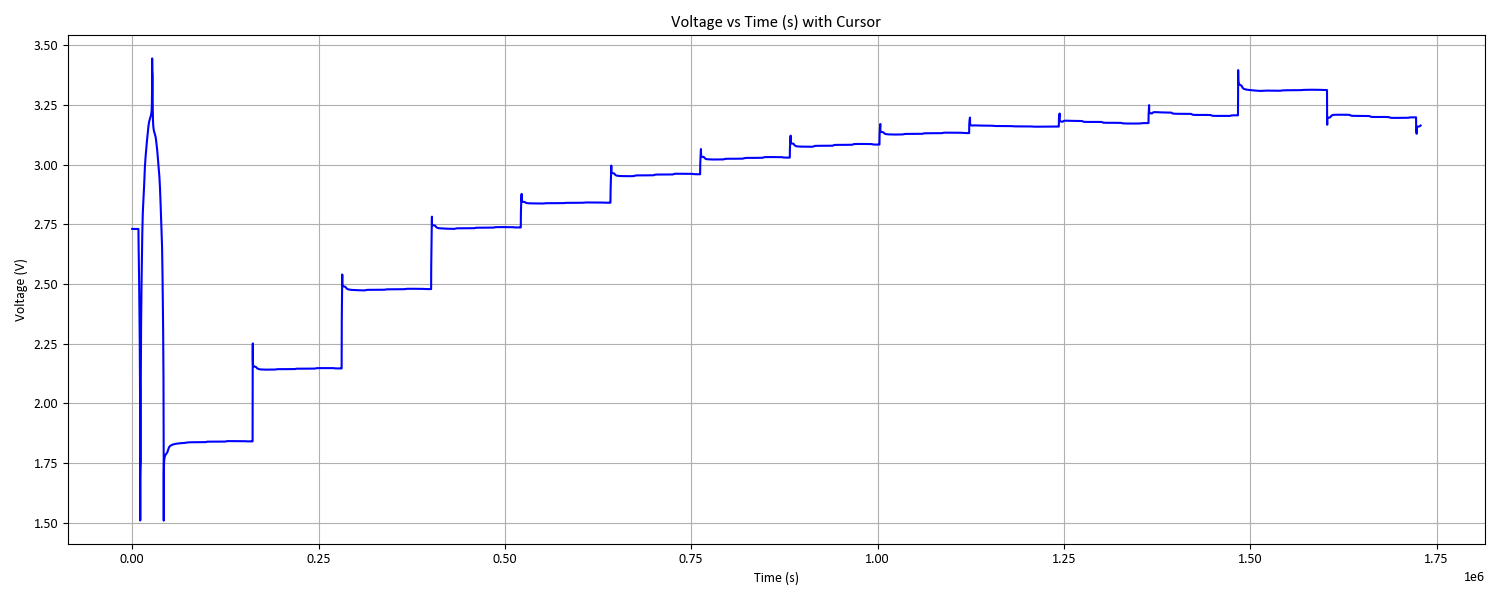

In [4]:
import matplotlib.pyplot as plt
%matplotlib widget
from matplotlib.widgets import Cursor

# Ensure voltage column exists
voltage_col = "1014 (Vdc)- Ch2_V"

fig, ax = plt.subplots(figsize=(15,6))
ax.plot(df2["Time_s"], df2[voltage_col], color="blue")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Voltage vs Time (s) with Cursor")
ax.grid(True)

# Add interactive cursor
cursor = Cursor(ax, useblit=True, color='red', linewidth=1)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# --- Define SOC segments and their time ranges in seconds ---
soc_segments = [
    ("0% SOC", 4.4e4, 1.58e5),
    ("2.5% SOC", 1.64e5, 2.77e5),
    ("10% SOC", 2.84e5, 3.96e5),
    ("20% SOC",4.03e5,5.19e5),
    ("30% SOC",5.24e5,6.38e5),
    ("40% SOC",6.44e5,7.60e5),
    ("50% SOC",7.65e5,8.80e5),
    ("60% SOC",8.85e5,1.001e6),
    ("70% SOC",1.006e6,1.121e6),
    ("80% SOC",1.126e6,1.241e6),
    ("90% SOC",1.245e6,1.361e6),
    ("97.5% SOC",1.367e6,1.480e6),
    ("100% SOC", 1.486e6, 1.599e6)
]

# --- Make sure dataframe is sorted by absolute time in seconds ---
df2 = df2.sort_values("Time_s").reset_index(drop=True)

# --- Initialize SOC_label column ---
df2["SOC_label"] = None

# --- Assign SOC labels based on the specified time ranges ---
for soc_label, t_start, t_end in soc_segments:
    mask = (df2["Time_s"] >= t_start) & (df2["Time_s"] <= t_end)
    df2.loc[mask, "SOC_label"] = soc_label

# --- Verify results ---
print(df2["SOC_label"].value_counts(dropna=False))
print("\nSOC labeling complete.")
print(f"Start time (s): {df2['Time_s'].iloc[0]}")
print(f"End time (s): {df2['Time_s'].iloc[-1]}")


SOC_label
None         48116
20% SOC      23200
60% SOC      23200
90% SOC      23200
40% SOC      23200
50% SOC      23000
70% SOC      23000
80% SOC      23000
30% SOC      22800
0% SOC       22800
97.5% SOC    22600
2.5% SOC     22600
100% SOC     22600
10% SOC      22400
Name: count, dtype: int64

SOC labeling complete.
Start time (s): 0.0
End time (s): 1728575.01


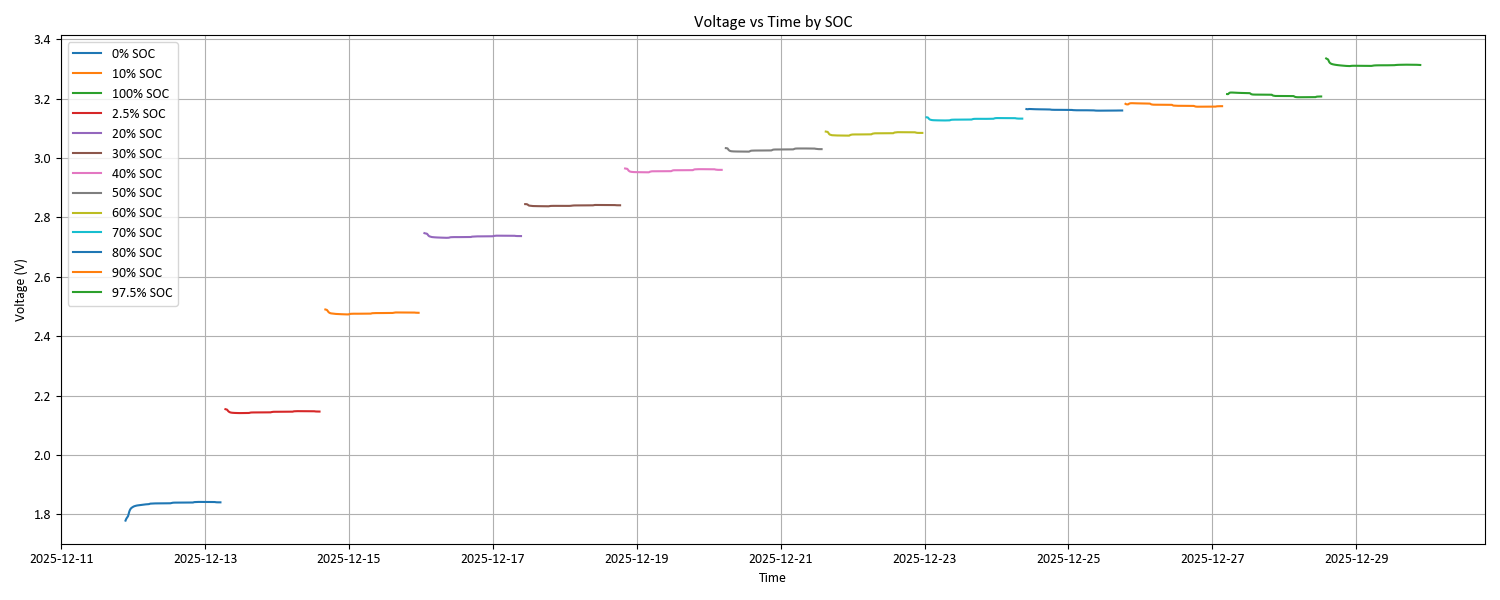

In [6]:
import matplotlib.pyplot as plt
%matplotlib widget
from matplotlib.widgets import Cursor


# use notebook for interactive features

# Ensure time is datetime if not already
if not pd.api.types.is_datetime64_any_dtype(df2["Scan Sweep Time (Sec)"]):
    df2["Scan Sweep Time (Sec)"] = pd.to_datetime(df2["Scan Sweep Time (Sec)"])

# Voltage column
voltage_col = "1014 (Vdc)- Ch2_V"

fig, ax = plt.subplots(figsize=(15,6))
for soc_label, group in df2.groupby("SOC_label"):
    ax.plot(group["Scan Sweep Time (Sec)"], group[voltage_col], label=soc_label)

ax.set_xlabel("Time")
ax.set_ylabel("Voltage (V)")
ax.set_title("Voltage vs Time by SOC")
ax.legend(loc="best")
ax.grid(True)
plt.tight_layout()

# Add interactive cursor
cursor = Cursor(ax, useblit=True, color='red', linewidth=1)

plt.show()


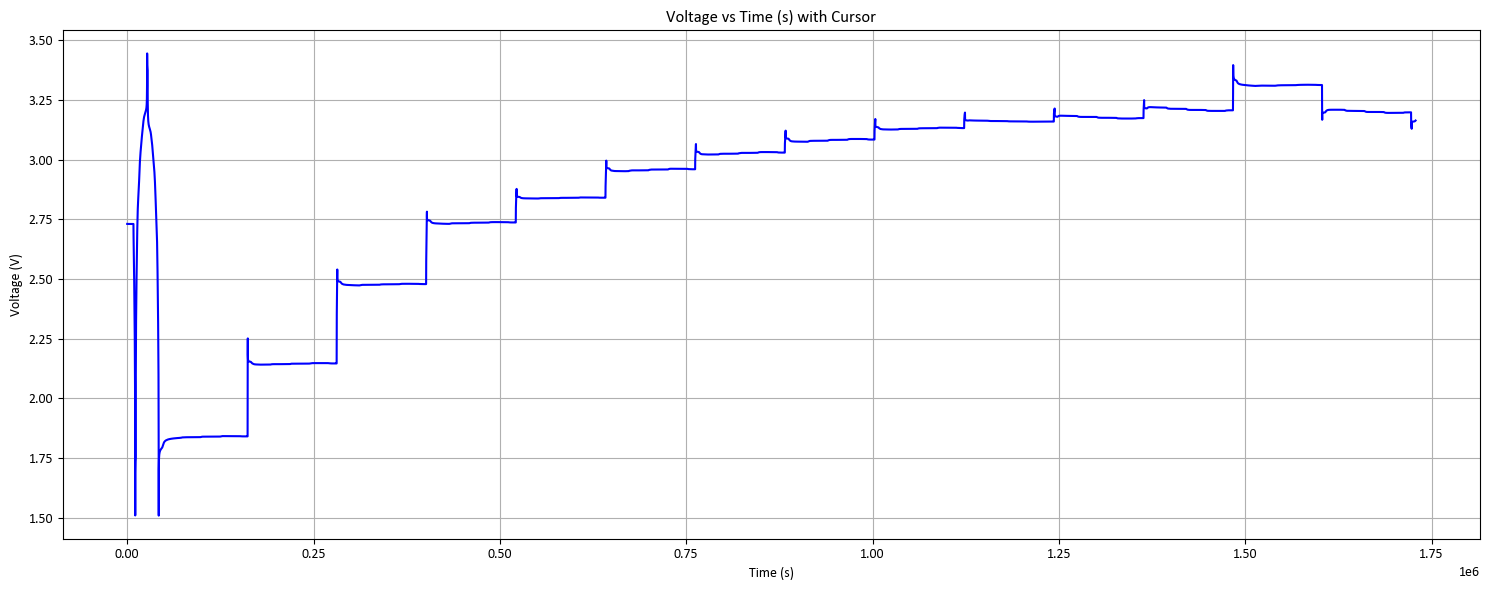

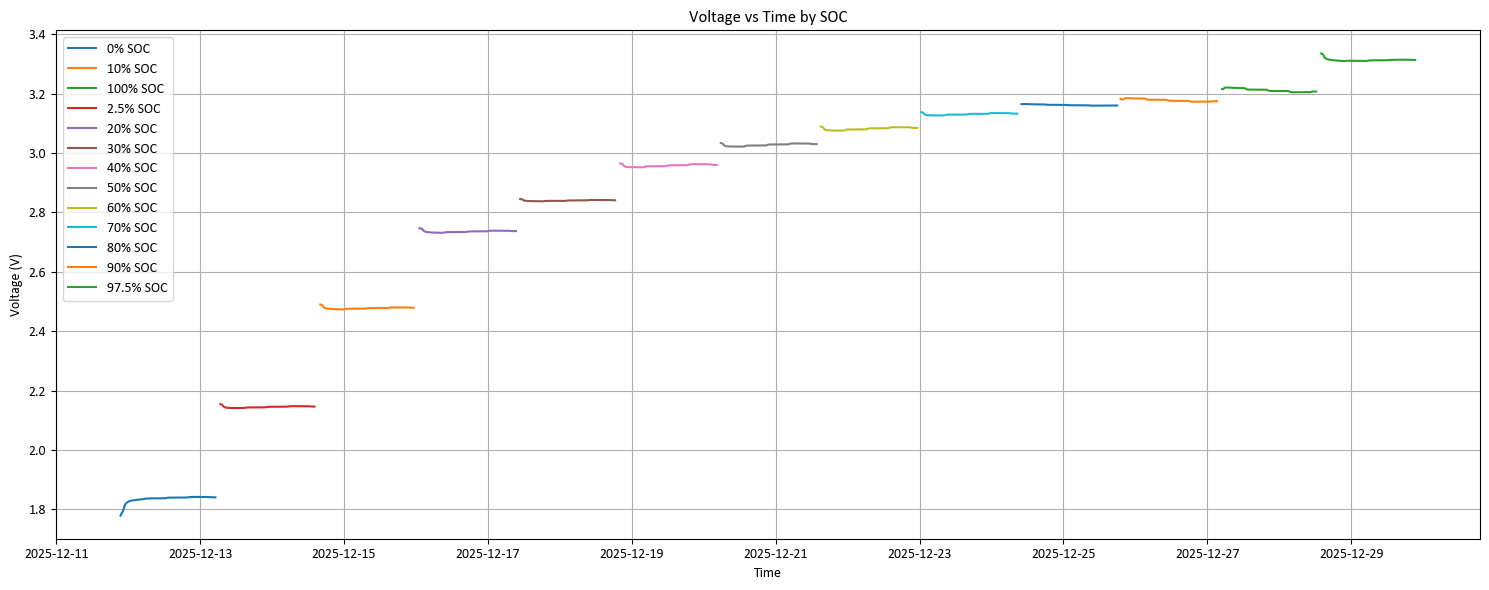

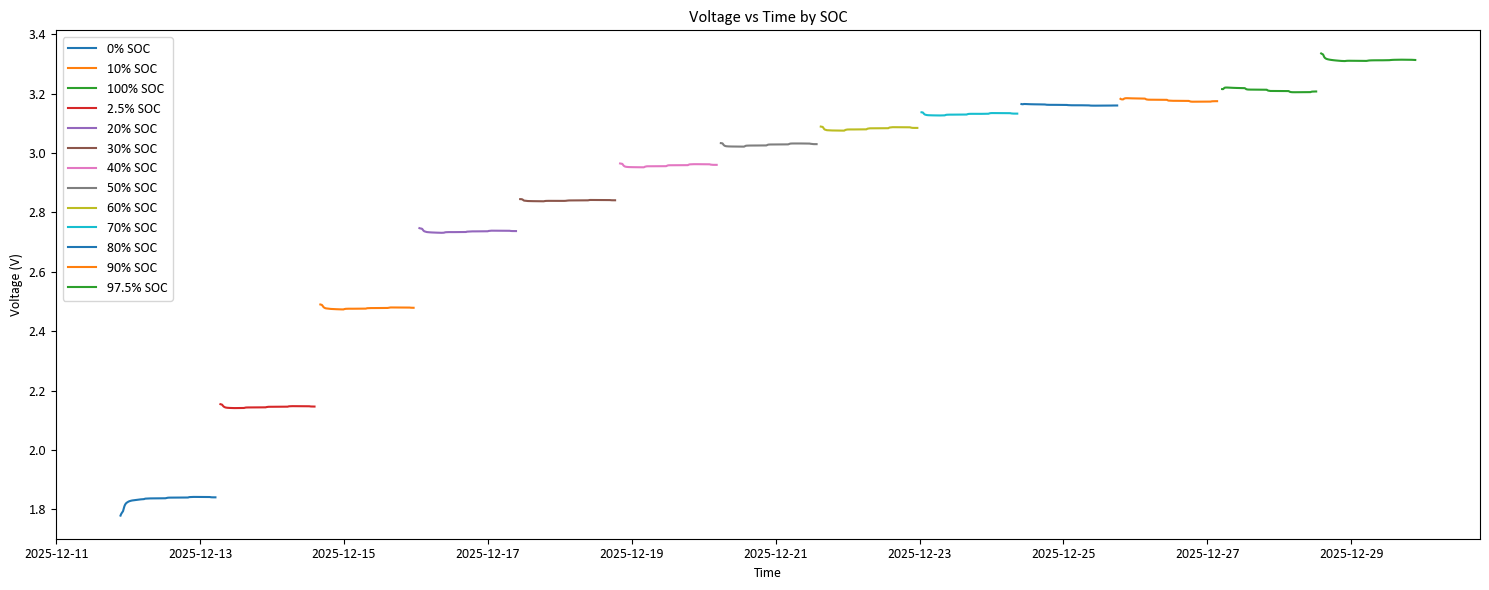

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

# Ensure time is datetime if not already
if not pd.api.types.is_datetime64_any_dtype(df2["Scan Sweep Time (Sec)"]):
    df2["Scan Sweep Time (Sec)"] = pd.to_datetime(df2["Scan Sweep Time (Sec)"])

# Voltage column
voltage_col = "1014 (Vdc)- Ch2_V"

plt.figure(figsize=(15,6))
for soc_label, group in df2.groupby("SOC_label"):
    plt.plot(group["Scan Sweep Time (Sec)"], group[voltage_col], label=soc_label)

plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Time by SOC")
plt.legend(loc="best")
plt.grid(False)
plt.tight_layout()

#plt.savefig("VoltageProfile_DL_example.png", dpi=300)

plt.show()


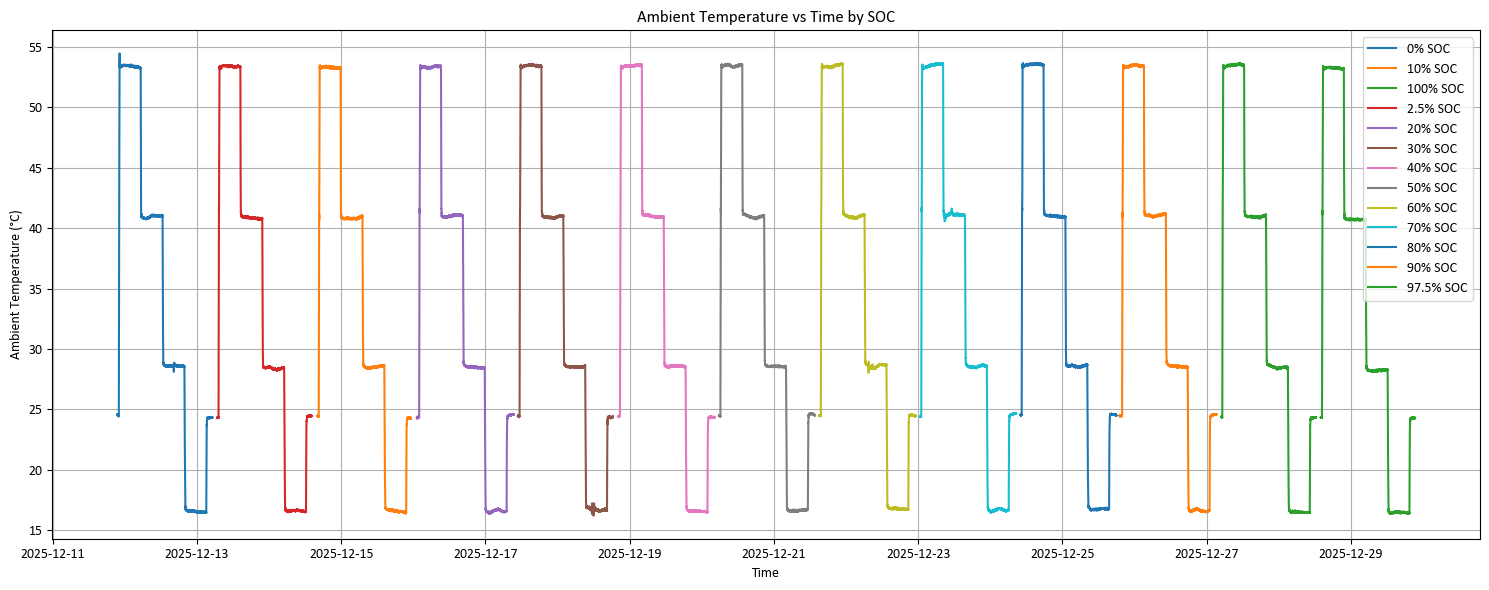

In [8]:
# Temperature column
temp_col = "1005 (°C)- Ambient Temp"

plt.figure(figsize=(15,6))
for soc_label, group in df2.groupby("SOC_label"):
    plt.plot(group["Scan Sweep Time (Sec)"], group[temp_col], label=soc_label)

plt.xlabel("Time")
plt.ylabel("Ambient Temperature (°C)")
plt.title("Ambient Temperature vs Time by SOC")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
#plt.savefig('Tambient_vs_Time_GT01_Ent_v1.png', dpi=300)
plt.show()


In [7]:
# --- Define temperature ranges and labels ---
temp_ranges = {
    "60degC": (53 - 1, 53 + 1),
    "45degC": (41 - 1, 41 + 1),
    "30degC": (28 - 1, 28 + 1),
    "15degC": (16 - 1, 16 + 1)
}

# --- Reference column ---
temp_col = "1005 (°C)- Ambient Temp"

# --- Initialize Temp_label column ---
df2["Temp_label"] = None

# --- Sequentially process each SOC label ---
for soc_label in df2["SOC_label"].dropna().unique():
    # Mask for current SOC
    soc_mask = df2["SOC_label"] == soc_label

    # Extract SOC data
    df_soc = df2.loc[soc_mask]

    # Loop over temperature ranges and apply labels
    for label, (t_min, t_max) in temp_ranges.items():
        mask = soc_mask & (df2[temp_col] >= t_min) & (df2[temp_col] <= t_max)
        df2.loc[mask, "Temp_label"] = label

# --- Verify results ---
label_counts = df2.groupby(["SOC_label", "Temp_label"]).size().reset_index(name="Count")
print(label_counts)



    SOC_label Temp_label  Count
0      0% SOC     15degC   5030
1      0% SOC     30degC   5108
2      0% SOC     45degC   5188
3      0% SOC     60degC   5054
4     10% SOC     15degC   5026
5     10% SOC     30degC   5111
6     10% SOC     45degC   5235
7     10% SOC     60degC   5045
8    100% SOC     15degC   5040
9    100% SOC     30degC   5124
10   100% SOC     45degC   5220
11   100% SOC     60degC   5046
12   2.5% SOC     15degC   5032
13   2.5% SOC     30degC   5117
14   2.5% SOC     45degC   5212
15   2.5% SOC     60degC   5046
16    20% SOC     15degC   5038
17    20% SOC     30degC   5104
18    20% SOC     45degC   5216
19    20% SOC     60degC   5049
20    30% SOC     15degC   4930
21    30% SOC     30degC   5106
22    30% SOC     45degC   5222
23    30% SOC     60degC   5039
24    40% SOC     15degC   5029
25    40% SOC     30degC   5107
26    40% SOC     45degC   5193
27    40% SOC     60degC   5056
28    50% SOC     15degC   5022
29    50% SOC     30degC   5100
30    50

In [10]:
# -----------------------------
# Export last 10 minutes of voltage data
# One sheet per temperature
# -----------------------------

import pandas as pd

# --- User parameters ---
time_col = "Scan Sweep Time (Sec)"          # adjust if needed
voltage_col = "1014 (Vdc)- Ch2_V"    # adjust if needed
export_filename = "last10min_voltage_by_temperature_char_2.xlsx"

# Ensure time column is numeric
df2[time_col] = pd.to_numeric(df2[time_col], errors="coerce")

# Create Excel writer
with pd.ExcelWriter(export_filename, engine="openpyxl") as writer:

    # Loop through each temperature label
    for temp, temp_group in df2.groupby("Temp_label"):

        if pd.isna(temp):
            continue

        export_list = []

        # Loop through SOCs within this temperature
        for soc, group in temp_group.groupby("SOC_label"):

            if pd.isna(soc):
                continue

            max_time = group[time_col].max()

            # Filter last 10 minutes
            last_10min = group[group[time_col] >= max_time - 600]

            subset = last_10min[[time_col, voltage_col]].copy()
            subset["SOC"] = soc

            export_list.append(subset)

        if export_list:
            temp_df = pd.concat(export_list, ignore_index=True)

            # Write to Excel sheet
            temp_df.to_excel(writer, sheet_name=str(temp), index=False)

print(f"✅ Data exported successfully to: {export_filename}")

✅ Data exported successfully to: last10min_voltage_by_temperature_char_2.xlsx


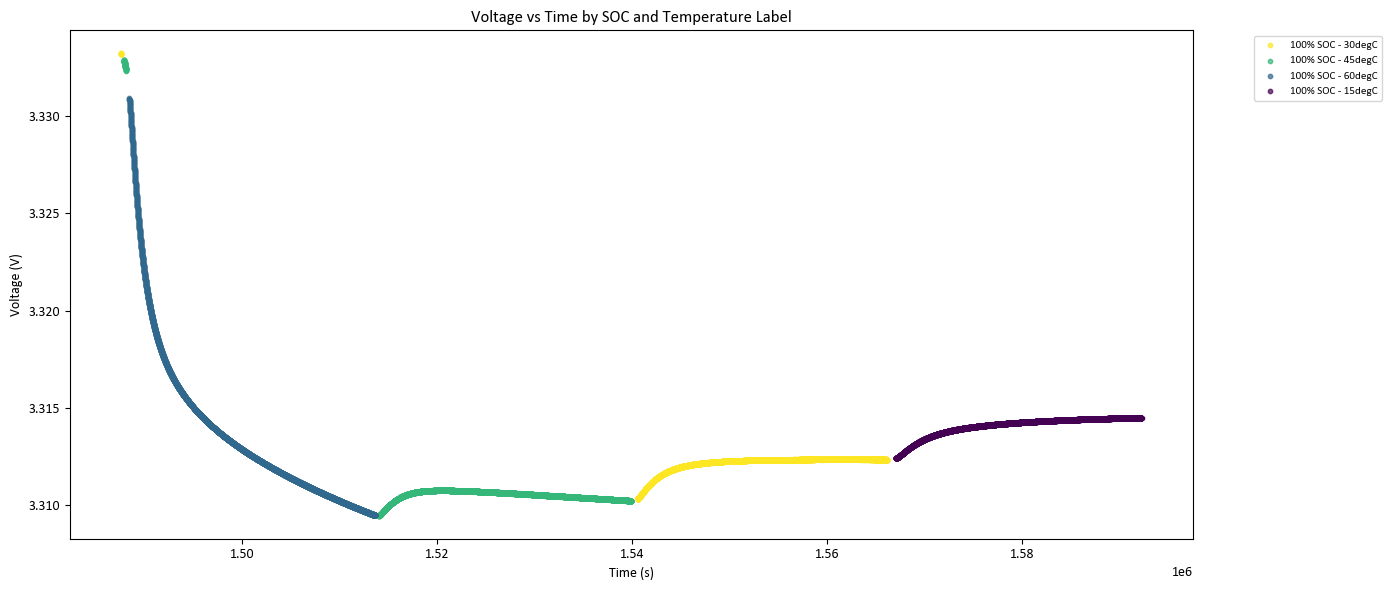

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Columns for plotting ---

time_col = "Time_s" if "Time_s" in df2.columns else "Scan Sweep Time (Sec)"
voltage_col = "1014 (Vdc)- Ch2_V"

# --- Sort data for clean plotting ---

df2 = df2.sort_values([time_col, "SOC_label"]).reset_index(drop=True)

# --- Create unique colors per Temp_label ---

temp_labels = df2["Temp_label"].dropna().unique()
colors = plt.cm.viridis_r(np.linspace(0, 1, len(temp_labels)))

# --- Plot SOC groups sequentially ---

fig, ax = plt.subplots(figsize=(14, 6))

for soc_label in df2["SOC_label"].dropna().unique():
    df_soc = df2[df2["SOC_label"] == soc_label]


for color, temp_label in zip(colors, temp_labels):
    df_temp = df_soc[df_soc["Temp_label"] == temp_label]
    if not df_temp.empty:
        ax.scatter(
            df_temp[time_col],
            df_temp[voltage_col],
            s=10,
            label=f"{soc_label} - {temp_label}",
            color=color,
            alpha=0.7
        )


# --- Format and labels ---

ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (V)")
ax.set_title("Voltage vs Time by SOC and Temperature Label")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

# --- Configuration ---
time_col = "Scan Sweep Time (Sec)"
voltage_col = "1014 (Vdc)- Ch2_V"
temp_col = "1005 (°C)- Ambient Temp"
window_seconds = 10 * 60  # 10 minutes

# --- Ensure time is in seconds ---
if pd.api.types.is_datetime64_any_dtype(df2[time_col]):
    # If the time column is datetime, convert to seconds relative to start
    df2["Time_s"] = (df2[time_col] - df2[time_col].min()).dt.total_seconds()
else:
    # If already numeric or string, cast to float
    df2["Time_s"] = df2[time_col].astype(float)

# --- Initialize result container ---
averages = []

# --- Group by SOC and Temp labels ---
for (soc, temp), group in df2.groupby(["SOC_label", "Temp_label"]):
    if group.empty:
        continue  # skip if no data in this group

    # Determine time cutoff for final 10 minutes in this group
    max_t = group["Time_s"].max()
    cutoff_t = max_t - window_seconds

    # Subset to final 10 minutes
    recent = group[group["Time_s"] >= cutoff_t]

    if not recent.empty:
        avg_voltage = recent[voltage_col].mean()
        avg_temp_C = recent[temp_col].mean()
        avg_temp_K = avg_temp_C + 273.15  # Convert to Kelvin
        averages.append({
            "SOC_label": soc,
            "Temp_label": temp,
            "Avg_Voltage(V)": avg_voltage,
            "Avg_Temp(K)": avg_temp_K,
            "Data_Points": len(recent)
        })

# --- Convert to DataFrame for display ---
avg_table = pd.DataFrame(averages).sort_values(["SOC_label", "Temp_label"]).reset_index(drop=True)

# --- Display results ---
print("Averaged voltage and temperature (final 10 min of each SOC & Temp, temperature in K):")
print(avg_table)


Averaged voltage and temperature (final 10 min of each SOC & Temp, temperature in K):
    SOC_label Temp_label  Avg_Voltage(V)  Avg_Temp(K)  Data_Points
0      0% SOC     15degC        1.841795   289.655322          121
1      0% SOC     30degC        1.839525   301.581496          121
2      0% SOC     45degC        1.837217   314.133767          120
3      0% SOC     60degC        1.834312   326.408140          121
4     10% SOC     15degC        2.480012   289.631529          121
5     10% SOC     30degC        2.477792   301.623388          121
6     10% SOC     45degC        2.475378   314.100694          121
7     10% SOC     60degC        2.473187   326.397322          121
8    100% SOC     15degC        3.314486   289.596075          120
9    100% SOC     30degC        3.312333   301.349430          121
10   100% SOC     45degC        3.310221   313.853289          121
11   100% SOC     60degC        3.309513   326.351562          121
12   2.5% SOC     15degC        2.147463   

C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_29756\3494696482.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(soc_labels))  # 'tab10' has 10 distinct colors; adjust if needed


📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_0.png


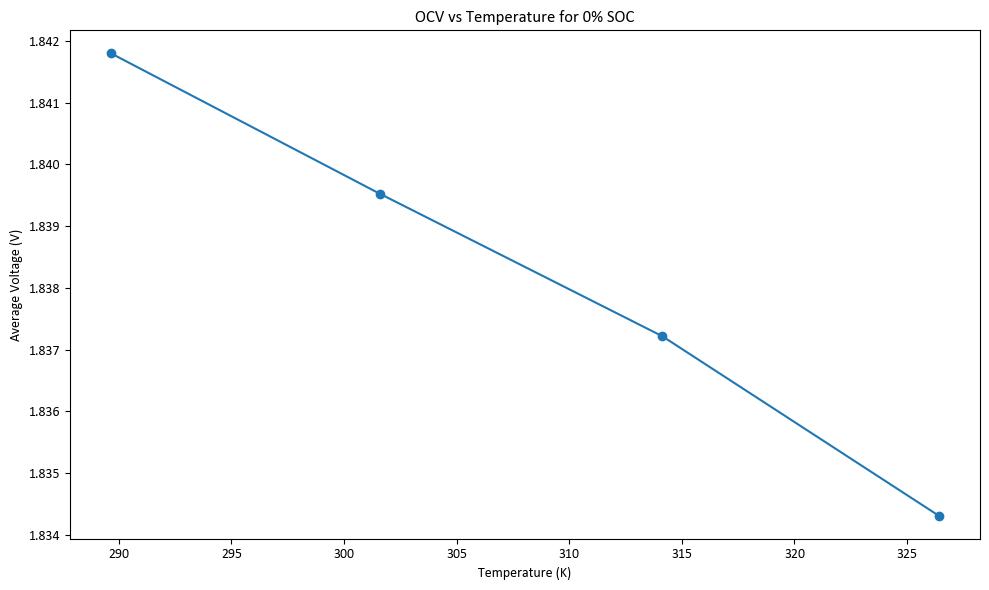

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_10.png


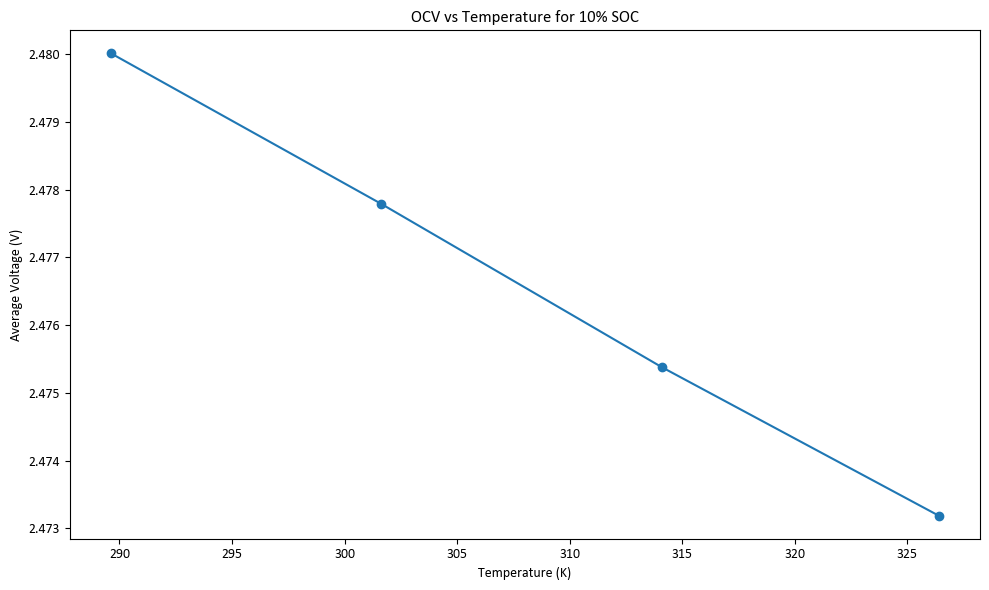

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_100.png


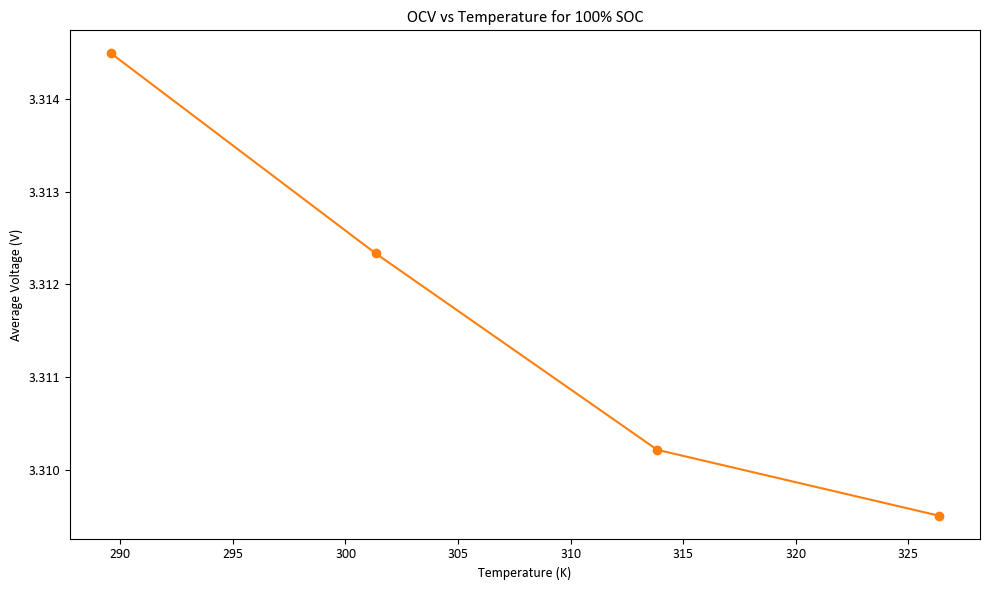

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_2.5.png


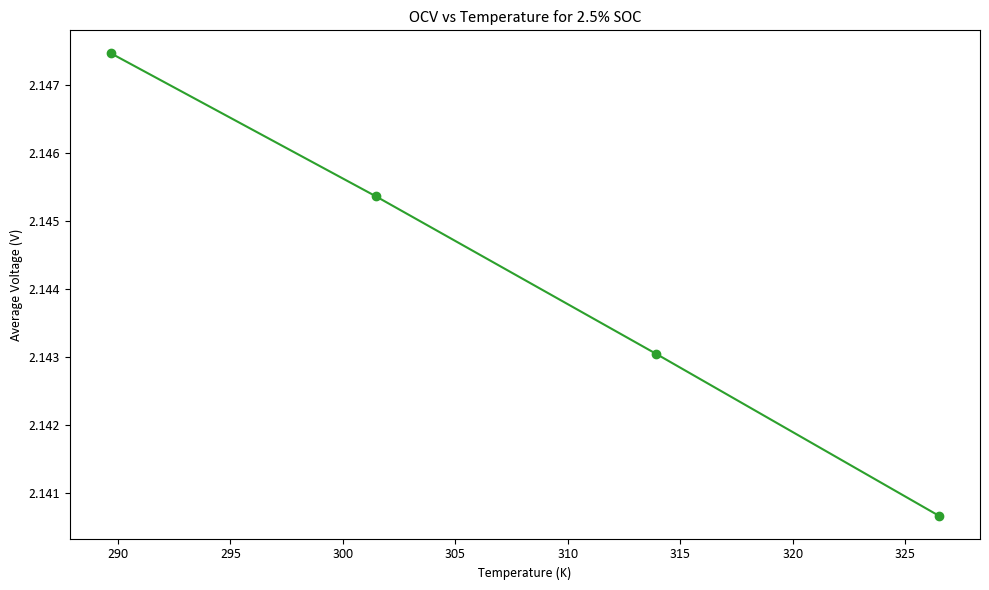

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_20.png


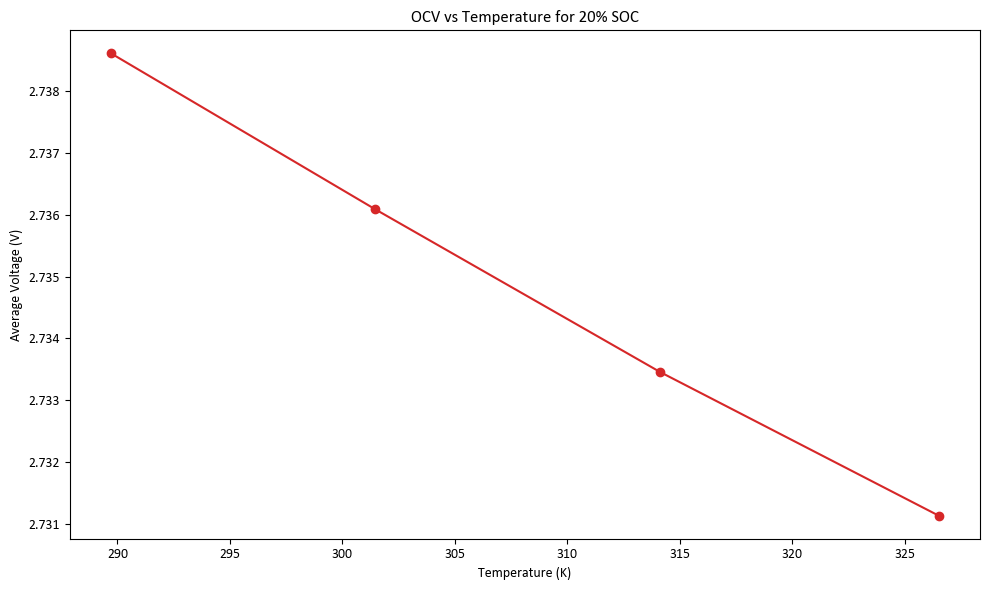

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_30.png


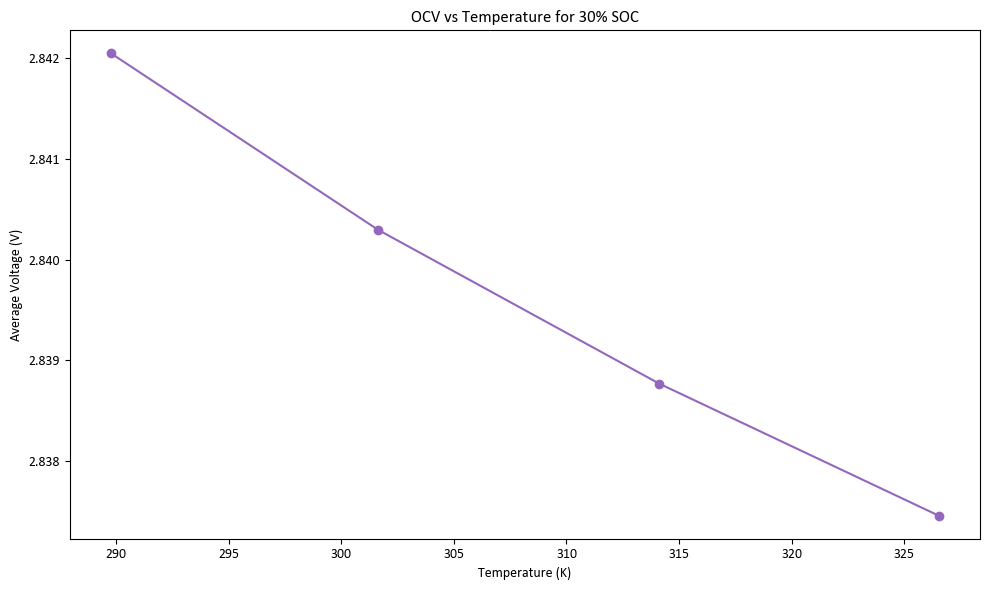

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_40.png


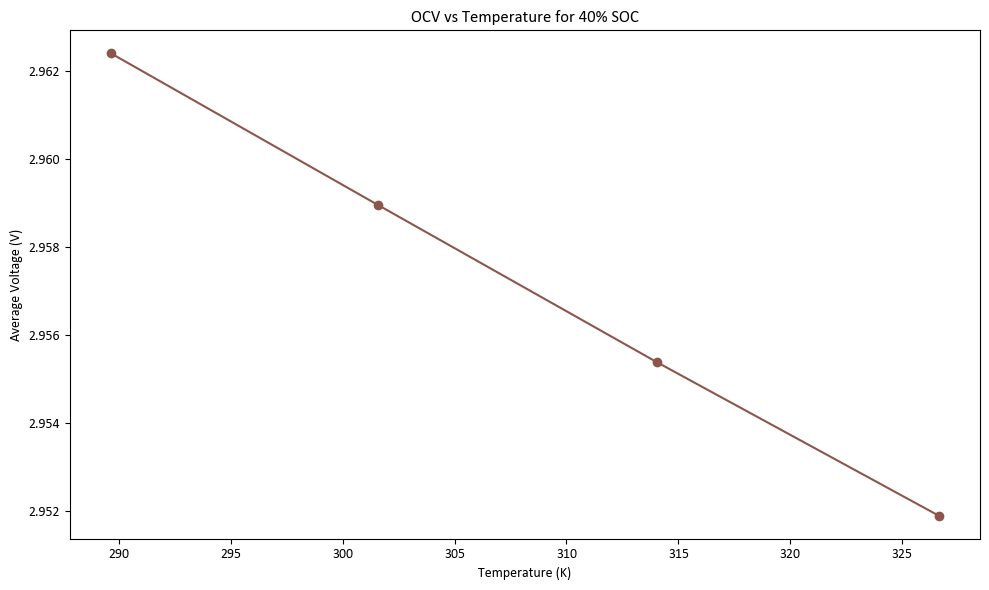

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_50.png


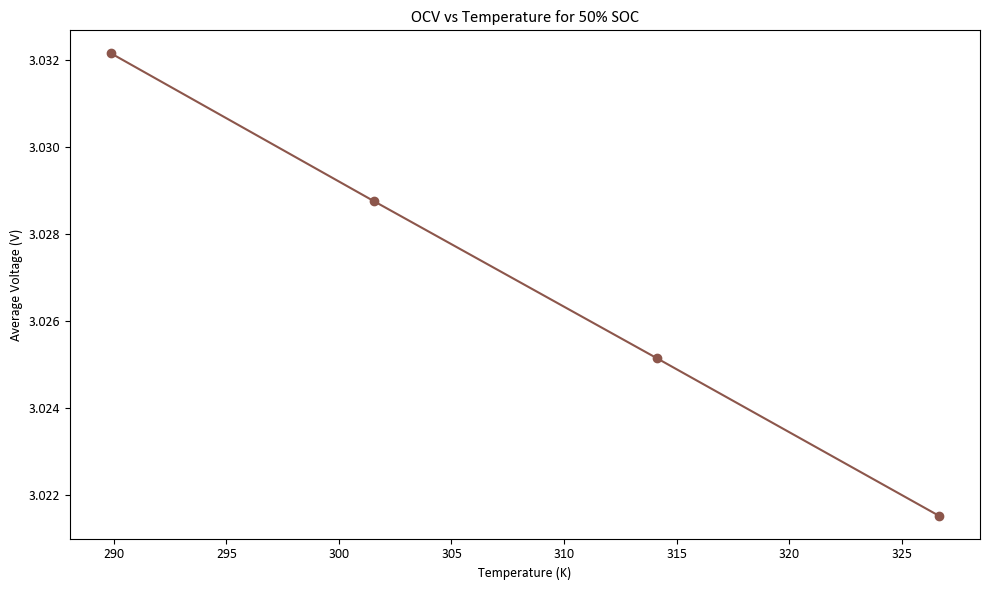

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_60.png


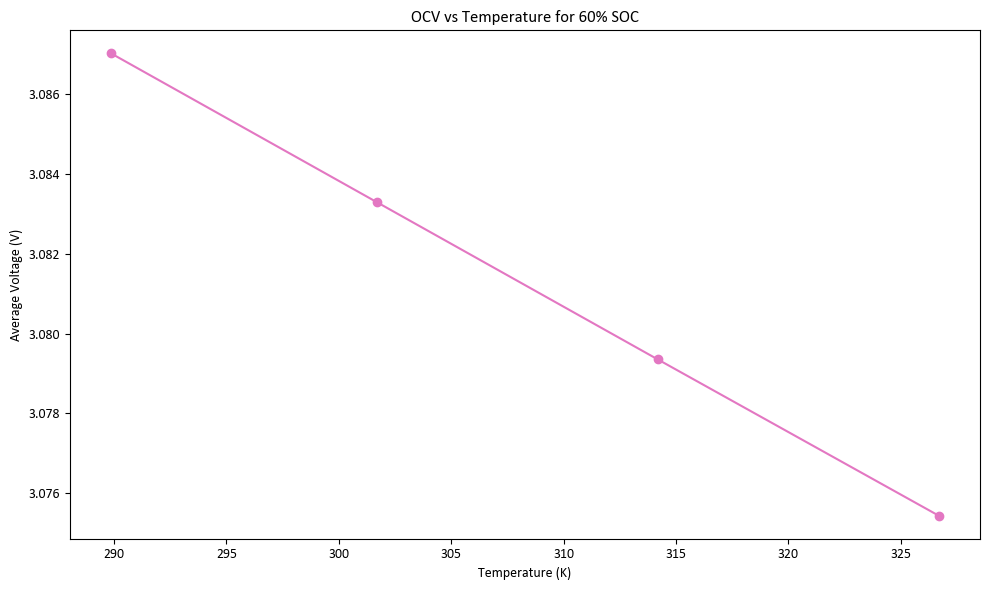

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_70.png


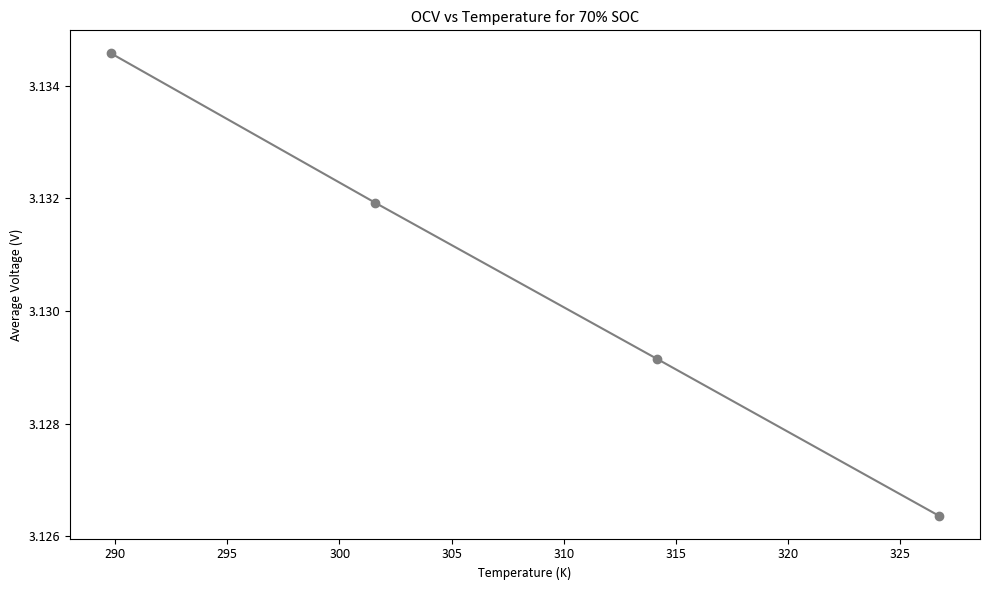

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_80.png


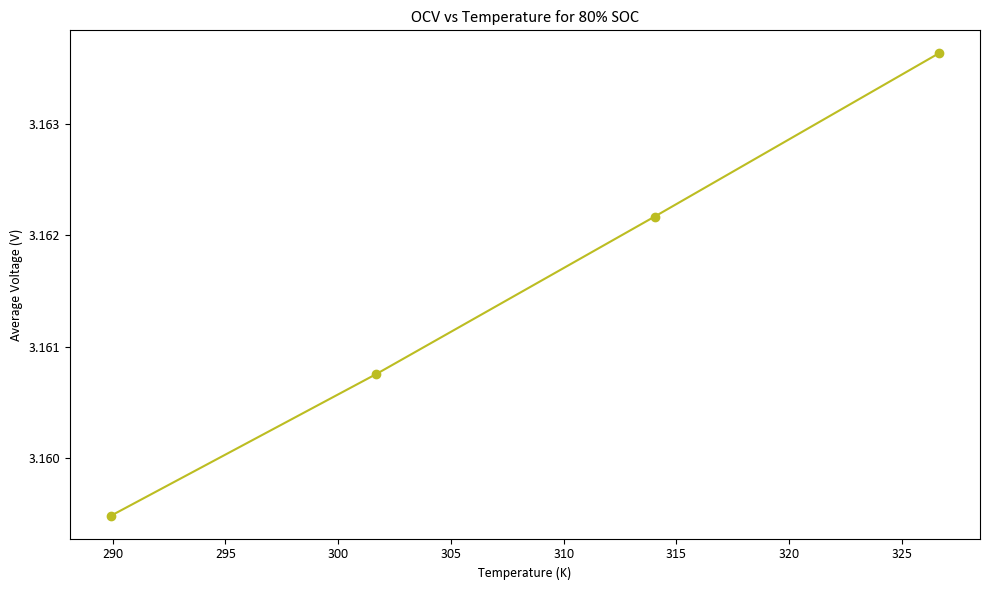

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_90.png


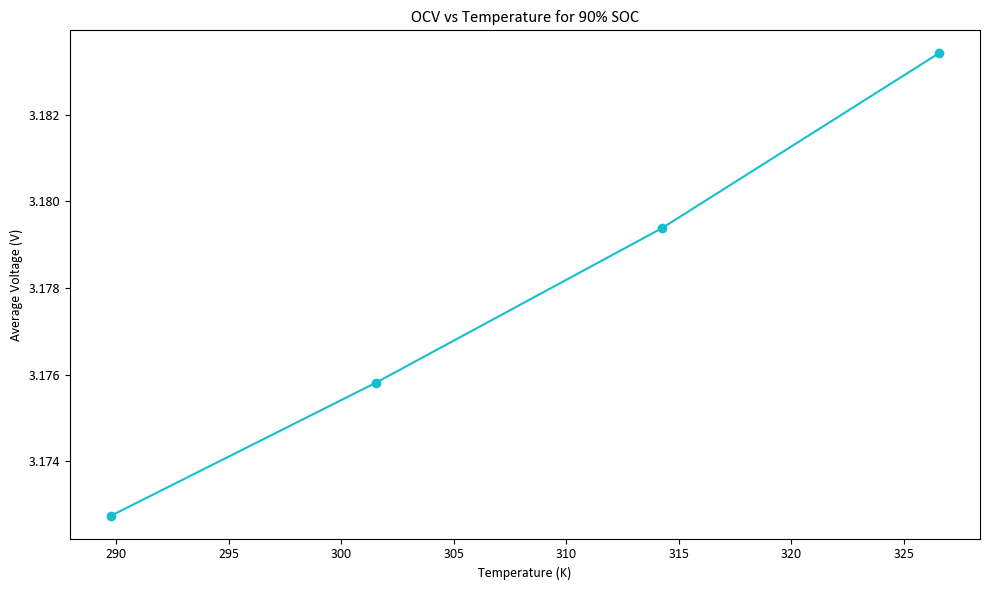

📁 Saved figure: OCV_vs_SOC_Figures_Char_Final\OCV_vs_Temp_SOC_97.5.png


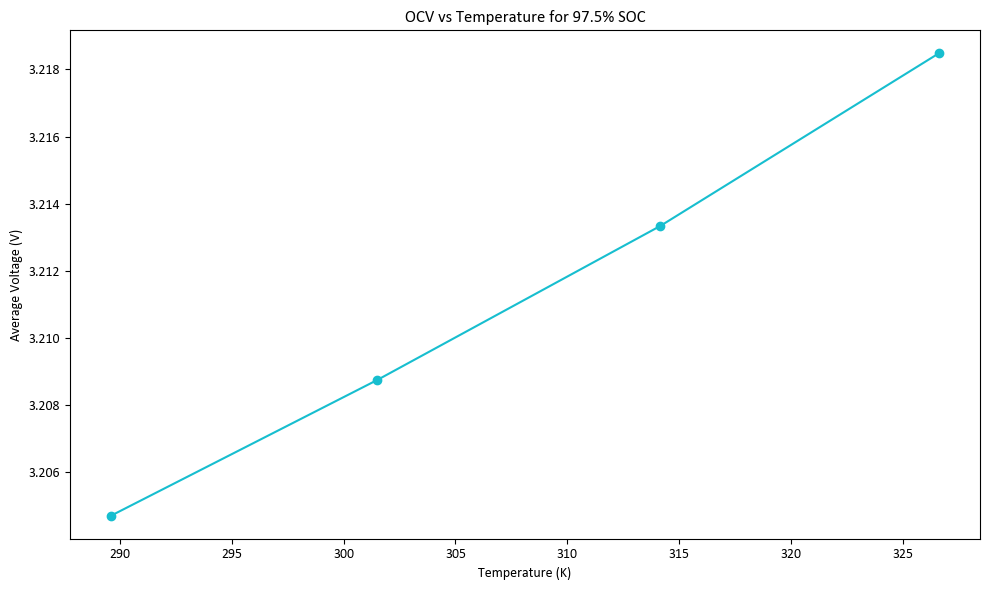

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
%matplotlib inline

# --------- Set the folder where figures will be saved ---------
save_folder = "OCV_vs_SOC_Figures_Char_Final"
os.makedirs(save_folder, exist_ok=True)

# --- Generate a color map based on number of SOCs ---
soc_labels = avg_table["SOC_label"].unique()
colors = cm.get_cmap("tab10", len(soc_labels))  # 'tab10' has 10 distinct colors; adjust if needed

# --- Loop over each SOC and create/save a separate figure ---
for i, soc in enumerate(soc_labels):
    
    # Clean SOC label for filename (remove spaces and % signs)
    soc_clean = soc.replace("% SOC", "").replace(" ", "")
    
    # Subset for current SOC
    soc_data = avg_table[avg_table["SOC_label"] == soc]

    plt.figure(figsize=(10, 6))
    plt.plot(
        soc_data["Avg_Temp(K)"],
        soc_data["Avg_Voltage(V)"],
        marker='o',
        linestyle='-',
        color=colors(i)
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel("Average Voltage (V)")
    plt.title(f"OCV vs Temperature for {soc}")
    plt.grid(False)
    plt.tight_layout()
    
    # --------- Save the figure ---------
    output_path = os.path.join(save_folder, f"OCV_vs_Temp_SOC_{soc_clean}.png")
    plt.savefig(output_path, dpi=300)
    print(f"📁 Saved figure: {output_path}")
    
    plt.show()


C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_12692\138892084.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(soc_labels))  # 'tab10' has 10 distinct colors; adjust if more


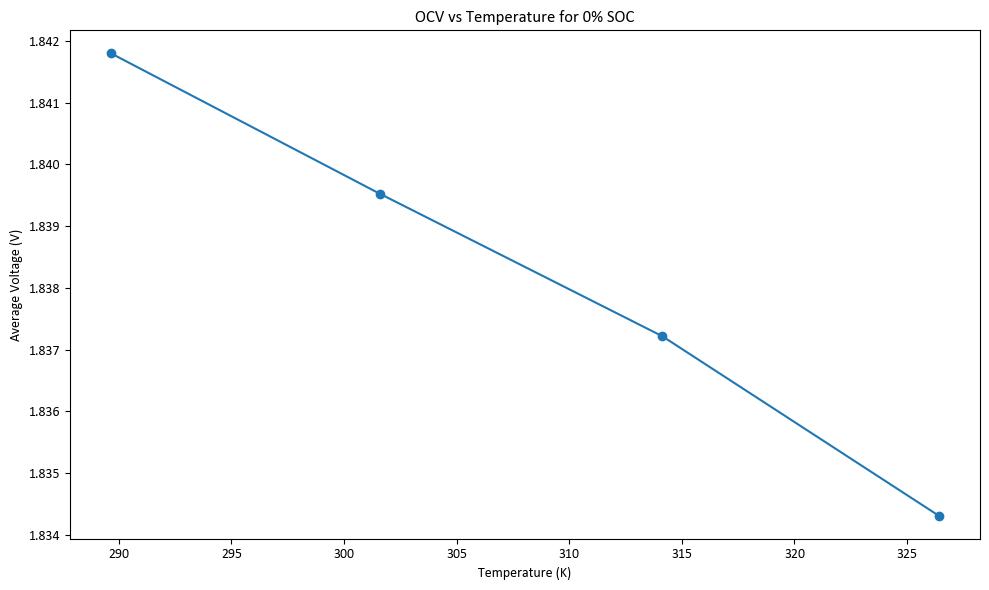

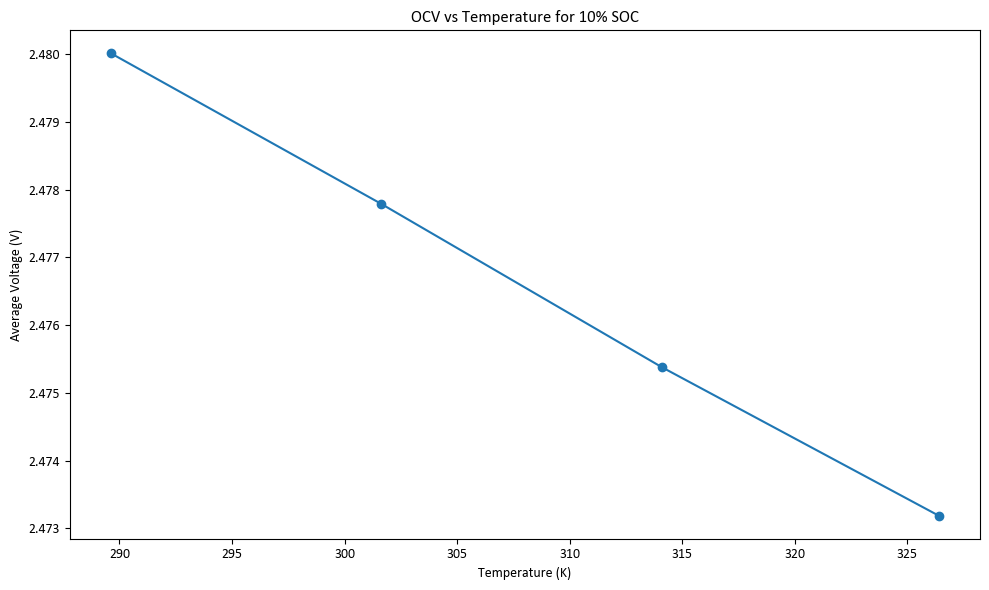

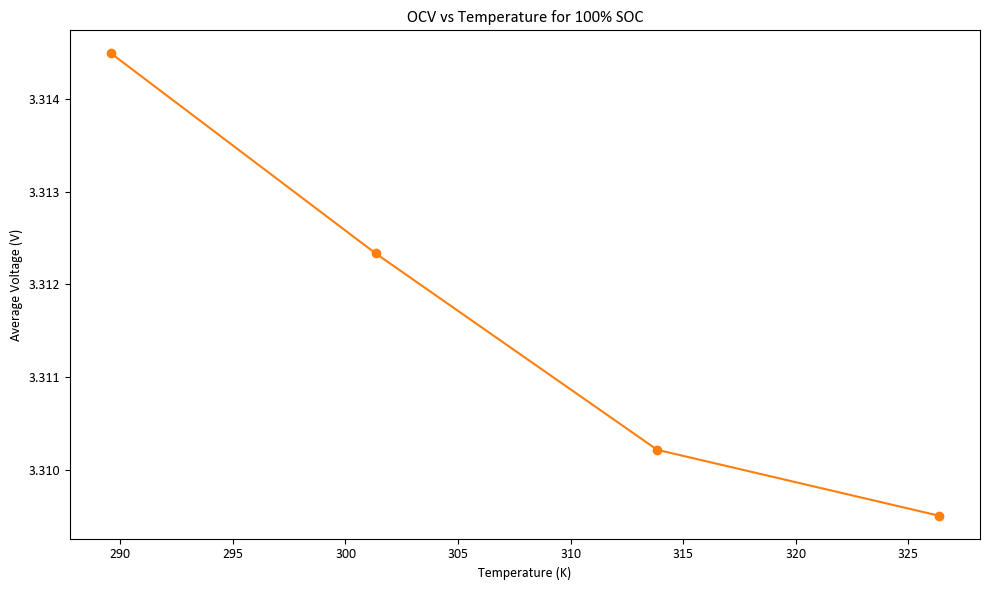

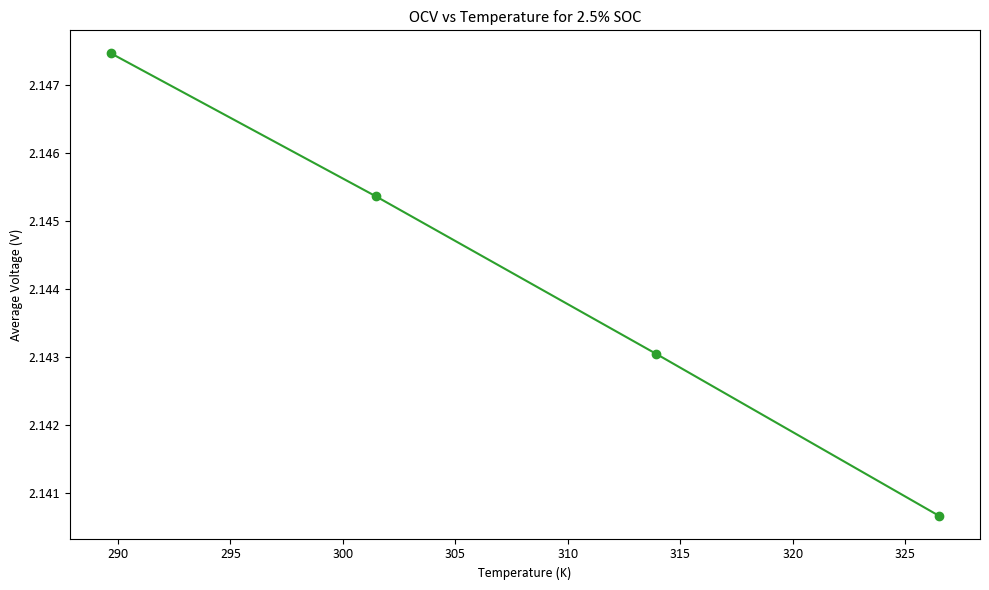

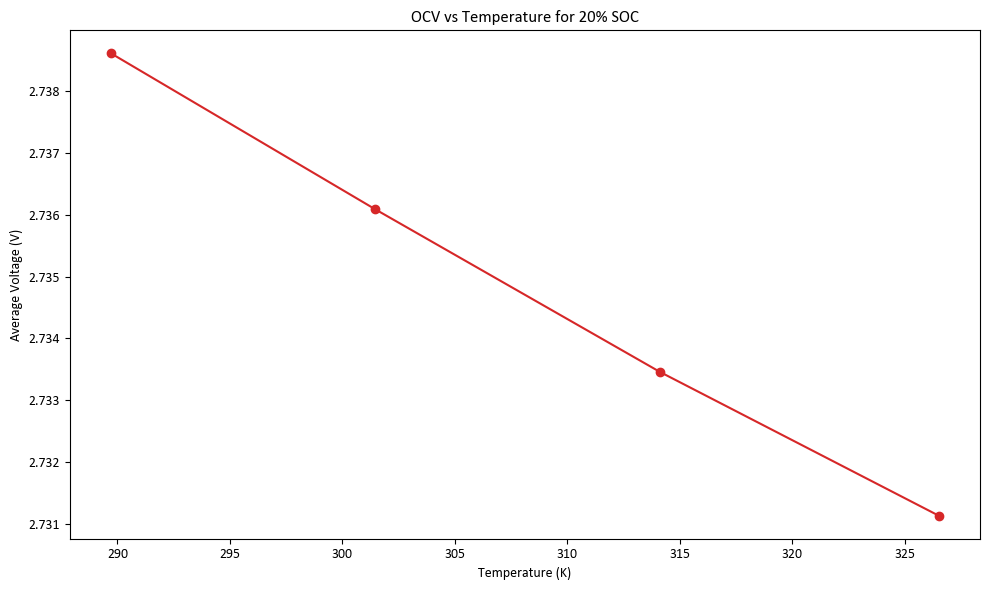

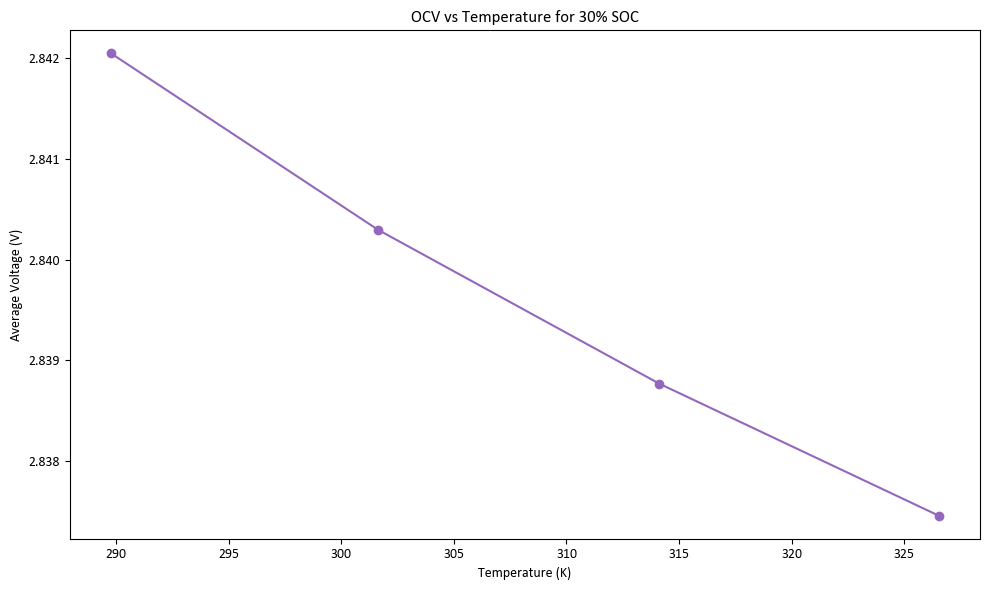

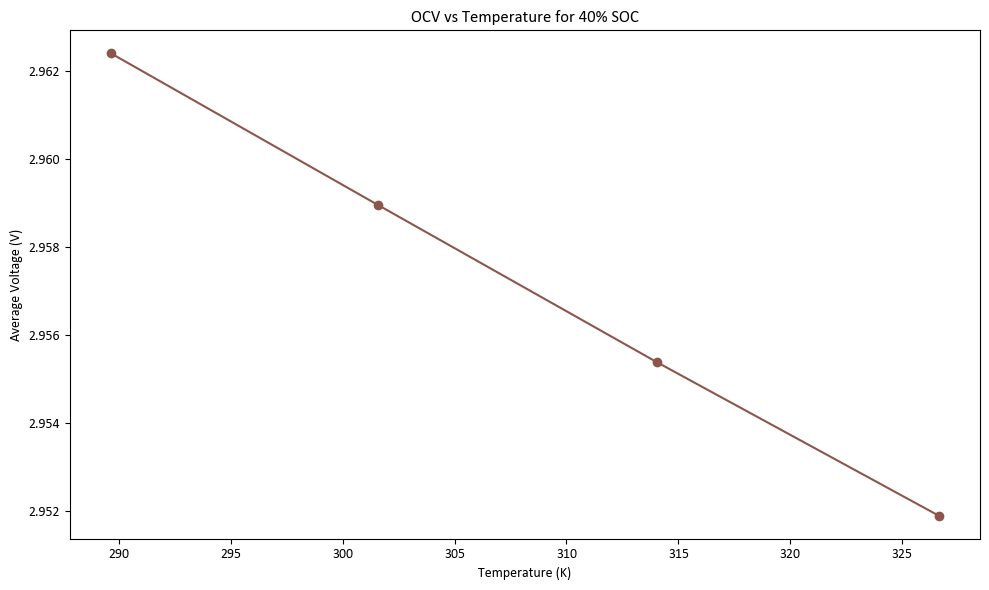

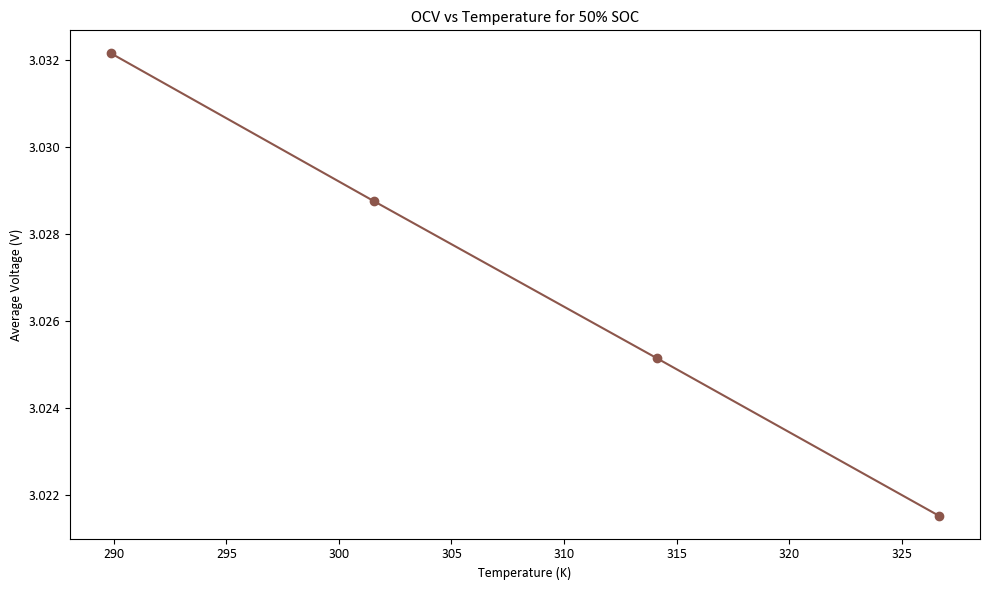

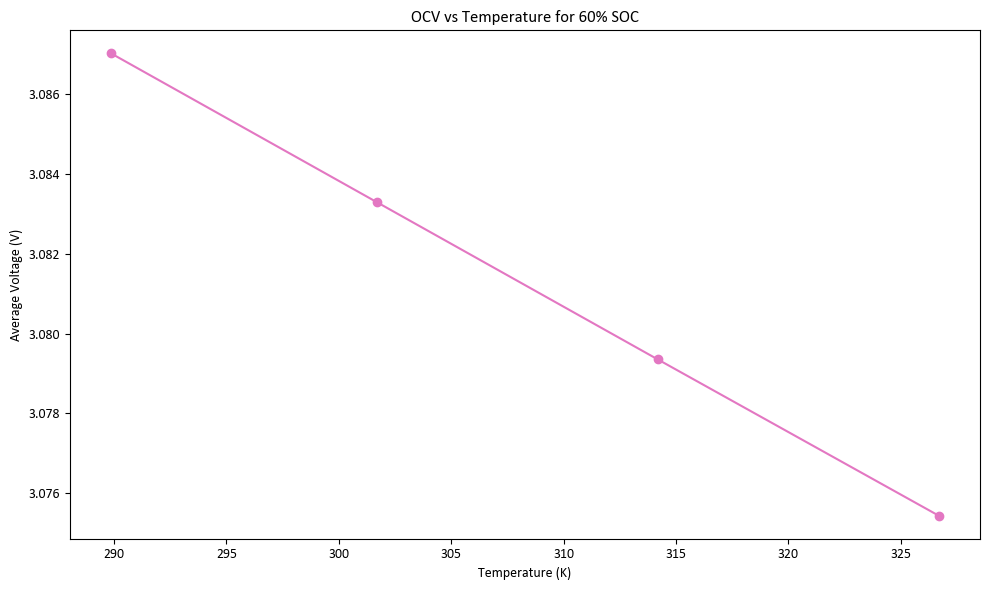

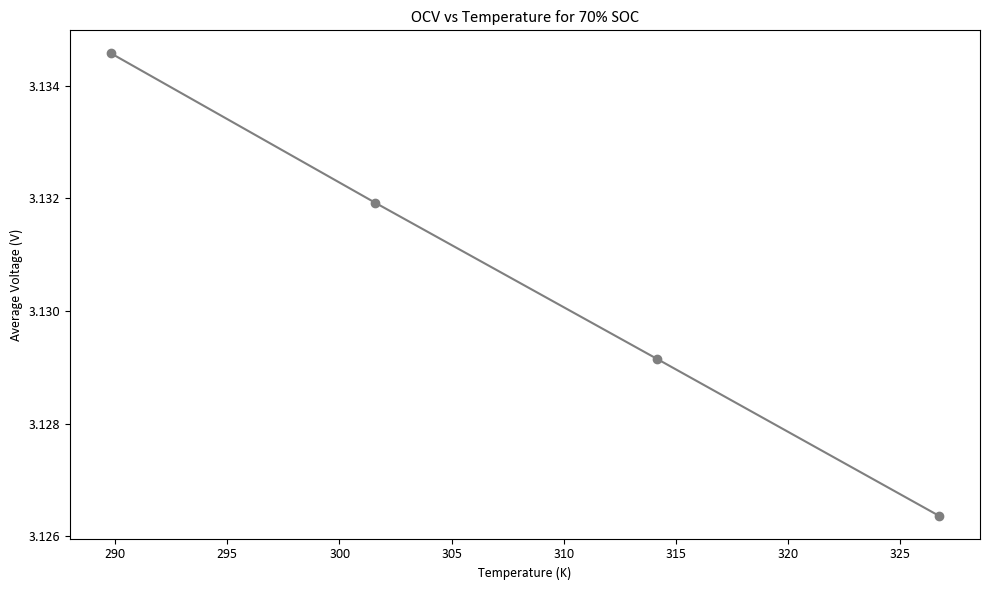

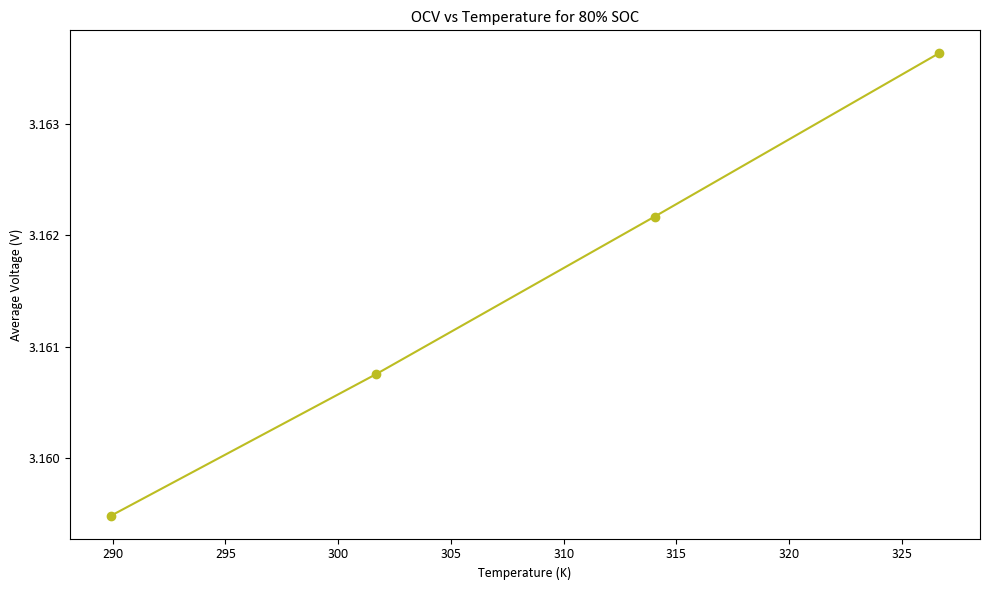

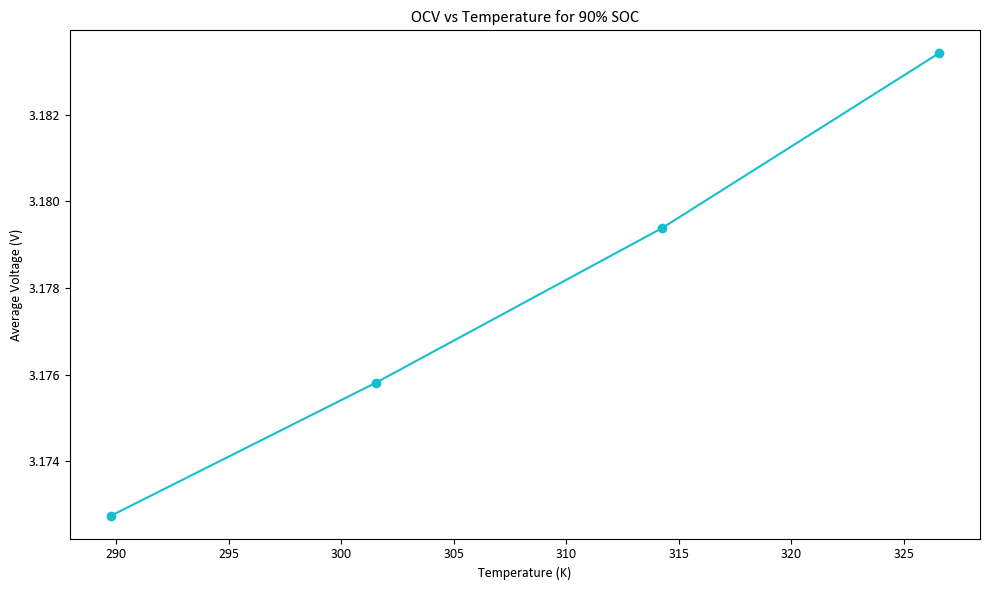

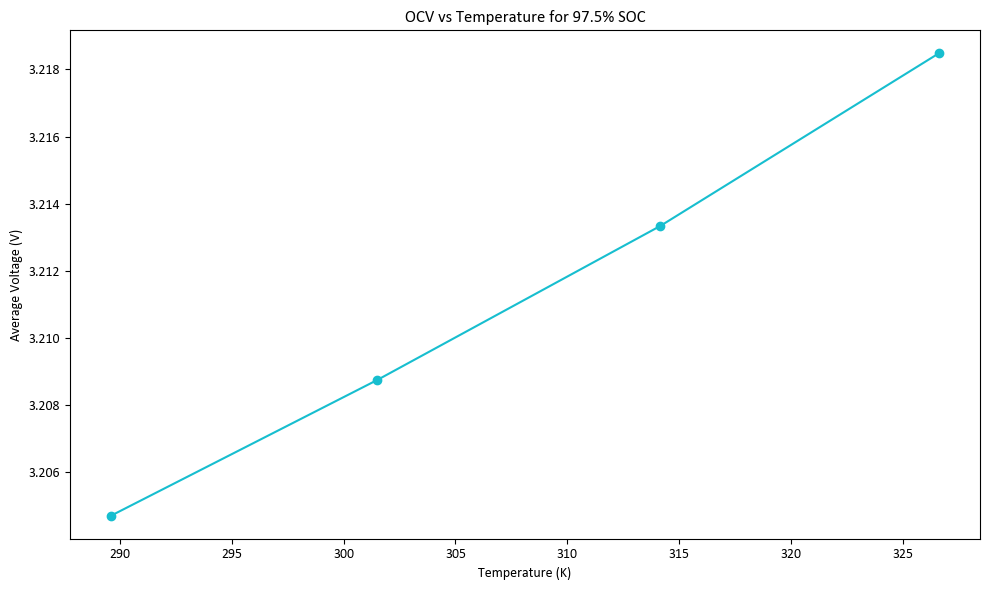

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
%matplotlib inline

# --- Generate a color map based on number of SOCs ---
soc_labels = avg_table["SOC_label"].unique()
colors = cm.get_cmap("tab10", len(soc_labels))  # 'tab10' has 10 distinct colors; adjust if more

# --- Loop over each SOC and create a separate figure with its own color ---
for i, soc in enumerate(soc_labels):
    # Subset for current SOC
    soc_data = avg_table[avg_table["SOC_label"] == soc]

    plt.figure(figsize=(10, 6))
    plt.plot(
        soc_data["Avg_Temp(K)"],
        soc_data["Avg_Voltage(V)"],
        marker='o',
        linestyle='-',
        color=colors(i)  # assign a unique color per SOC
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel("Average Voltage (V)")
    plt.title(f"OCV vs Temperature for {soc}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_12692\571490152.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(soc_labels))


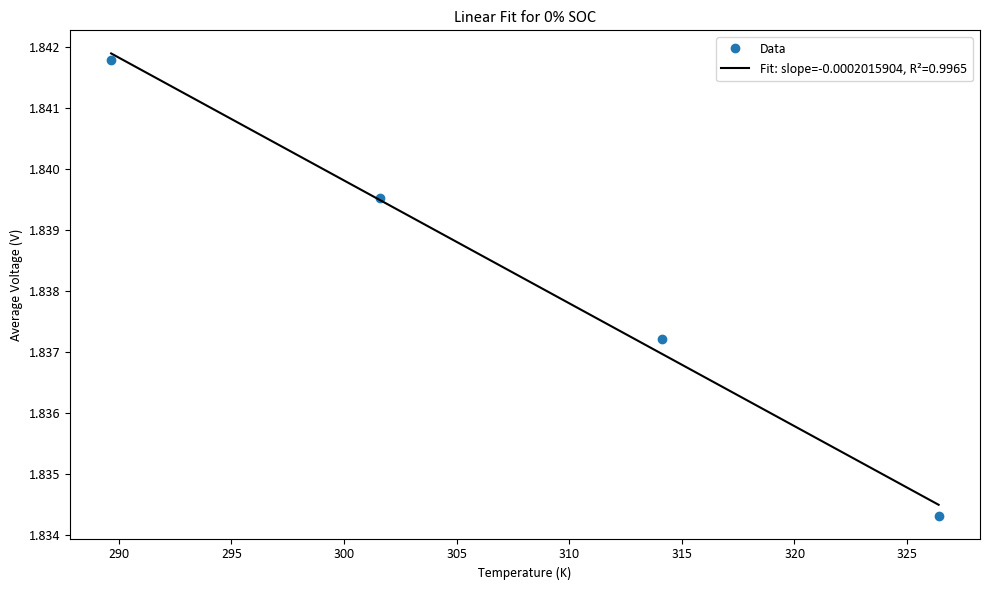

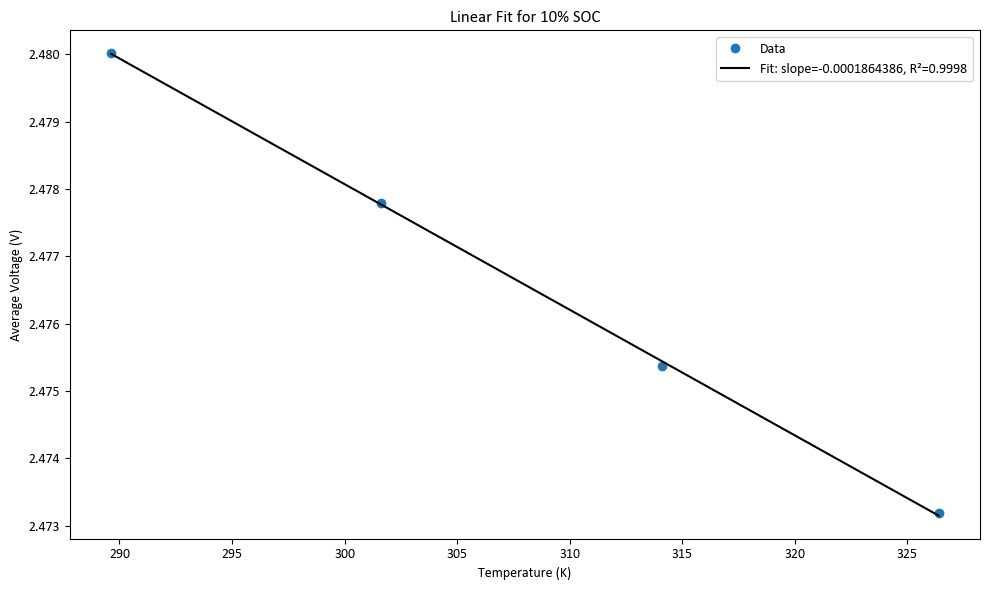

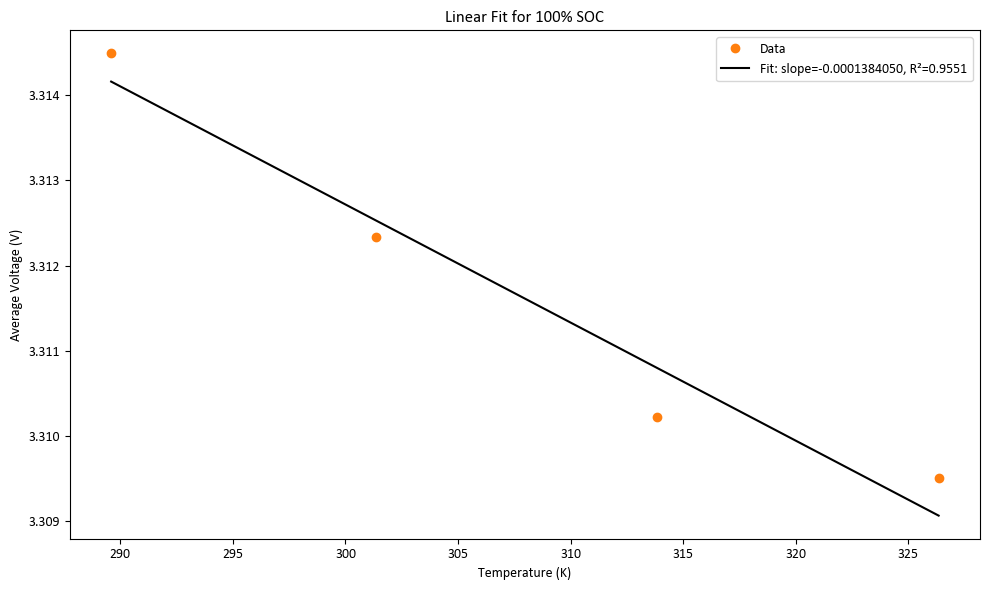

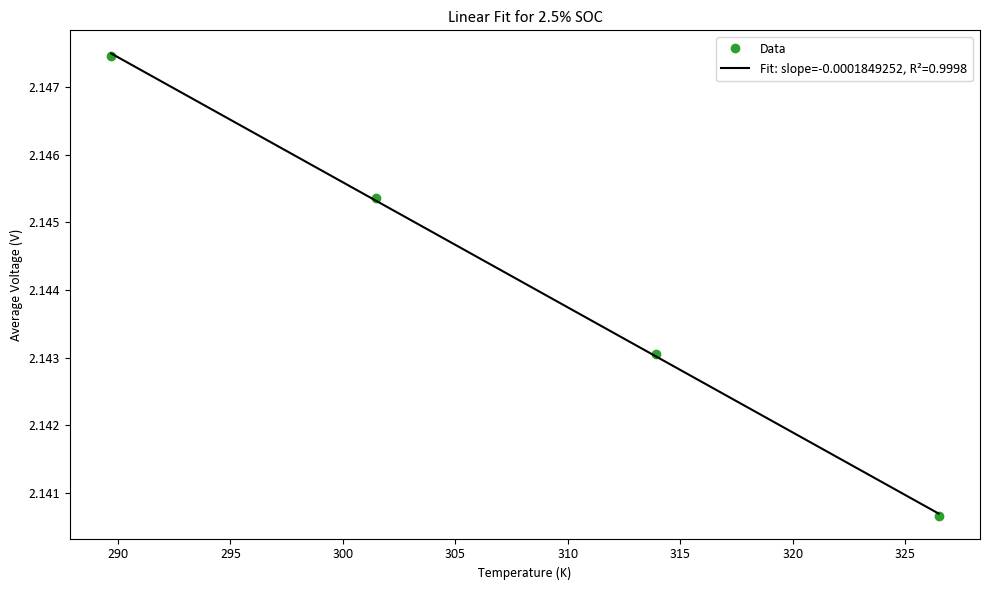

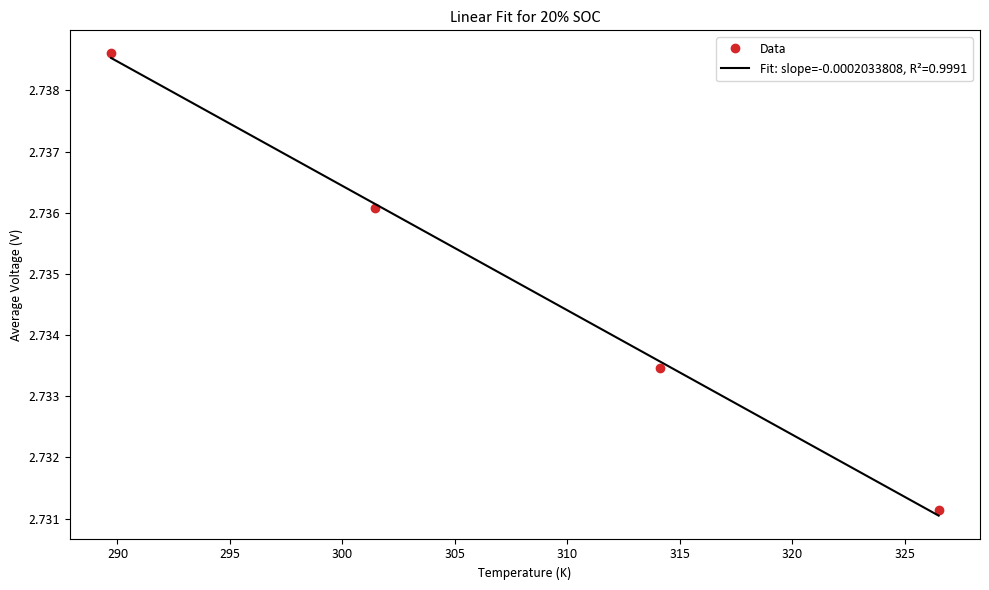

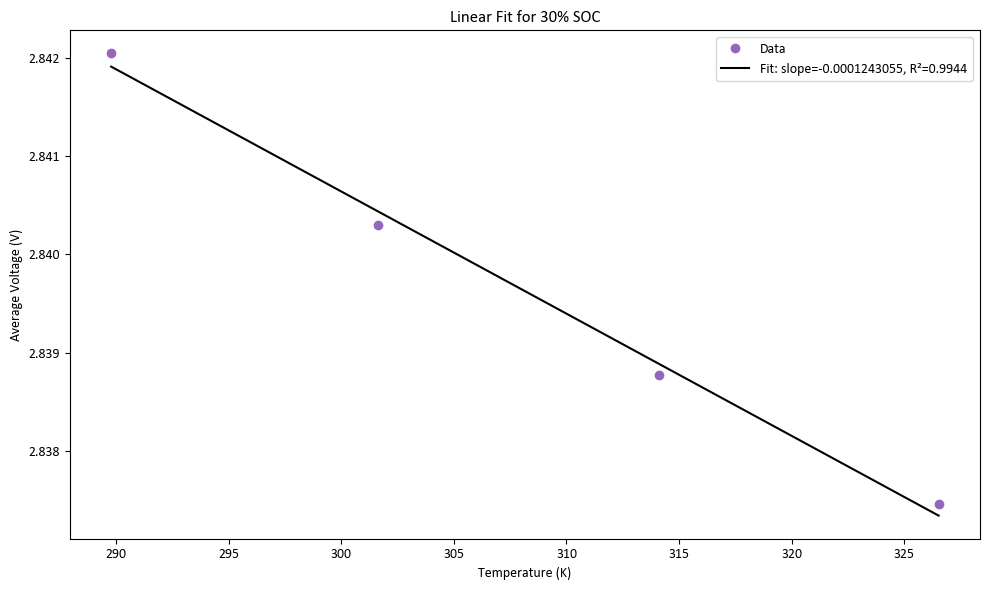

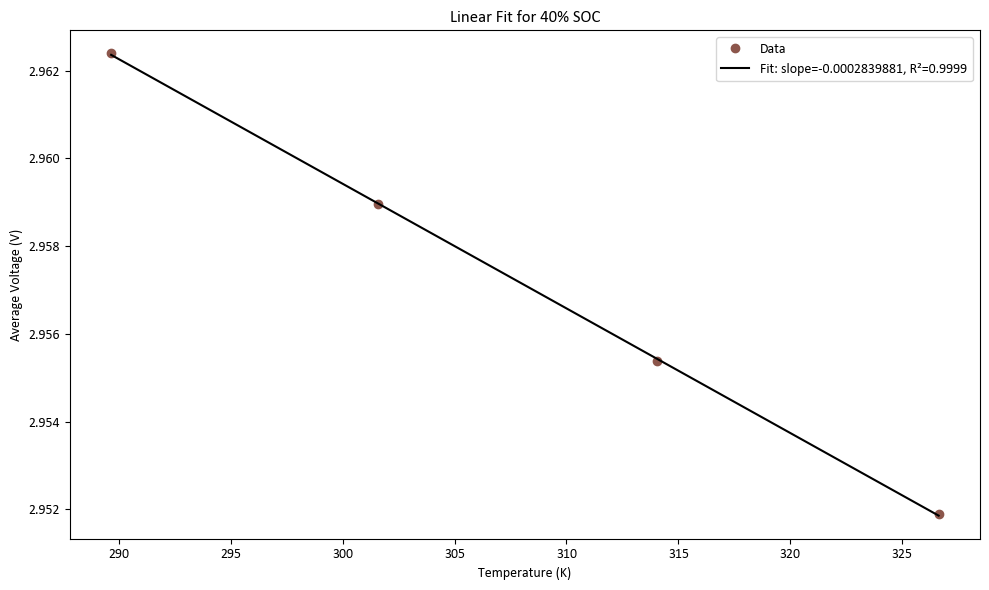

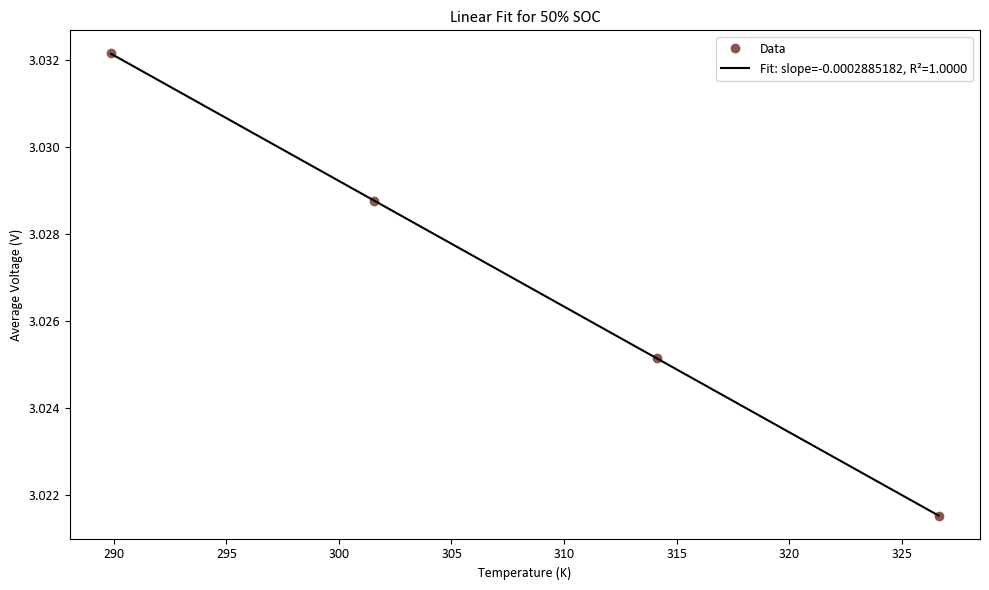

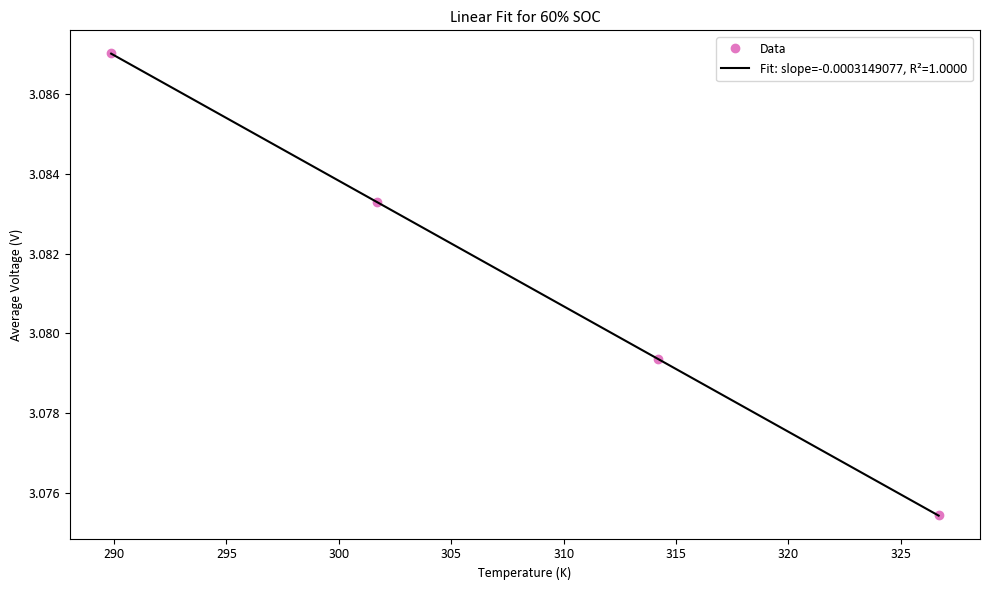

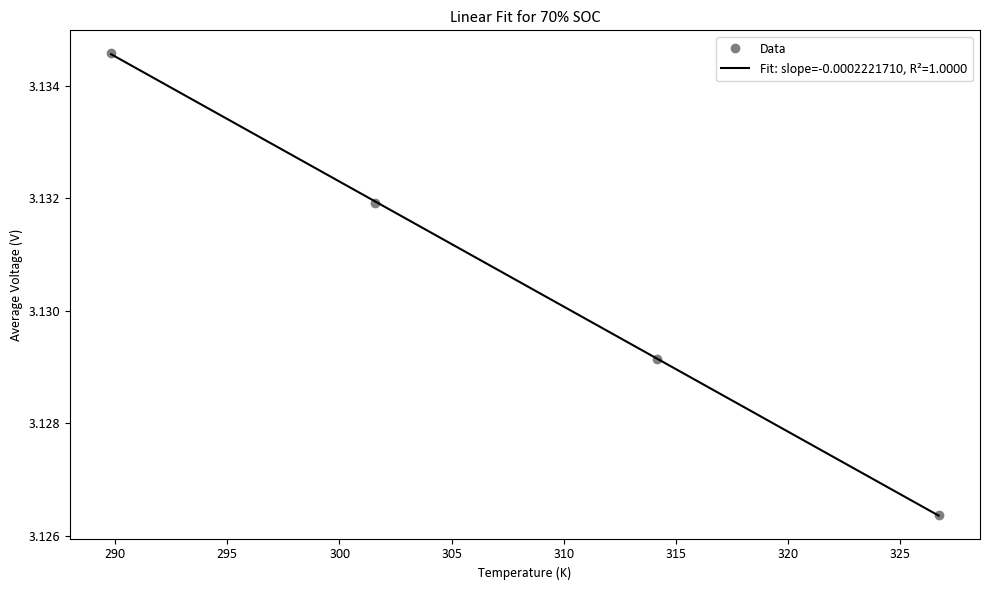

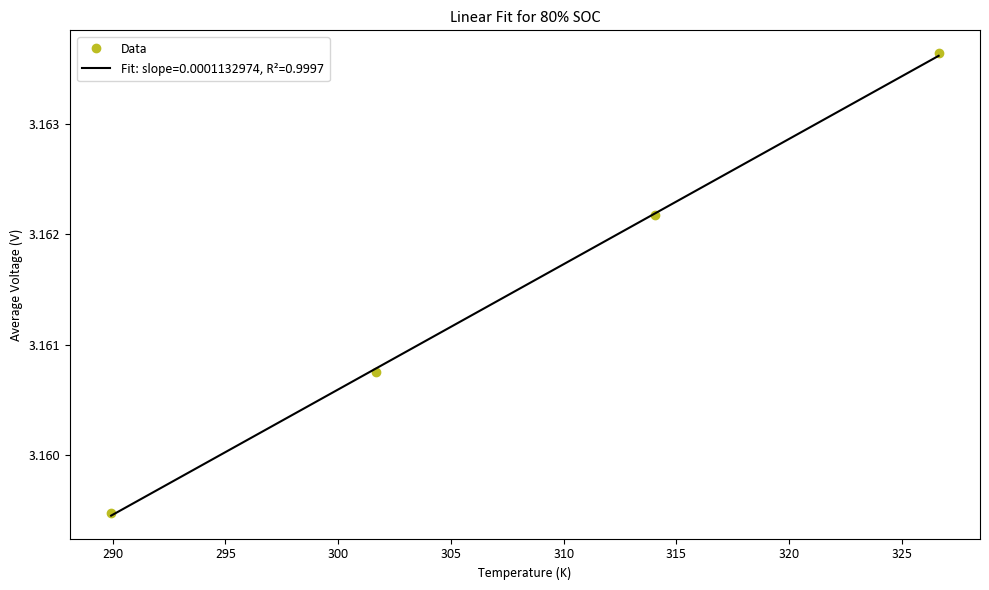

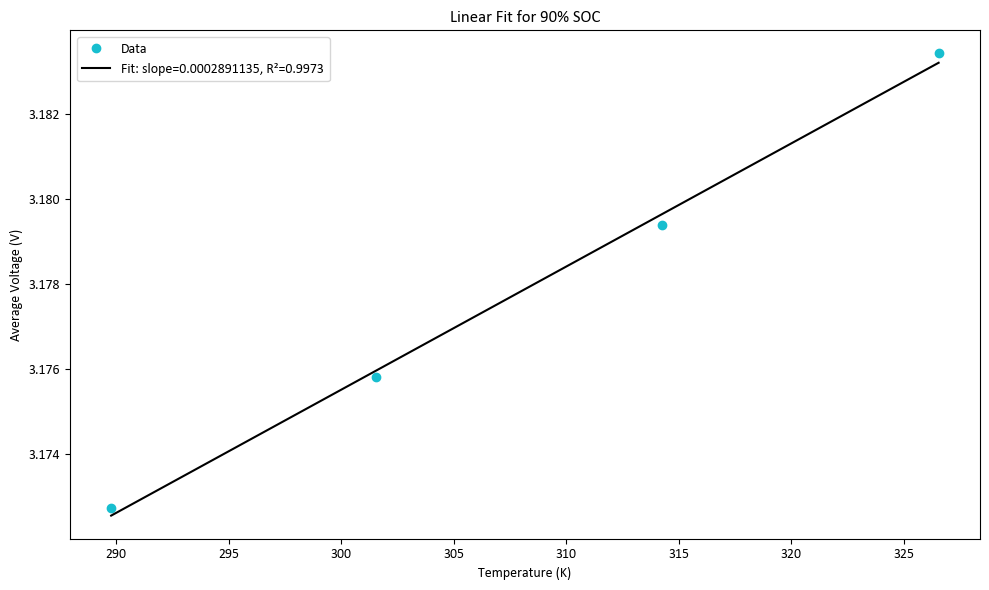

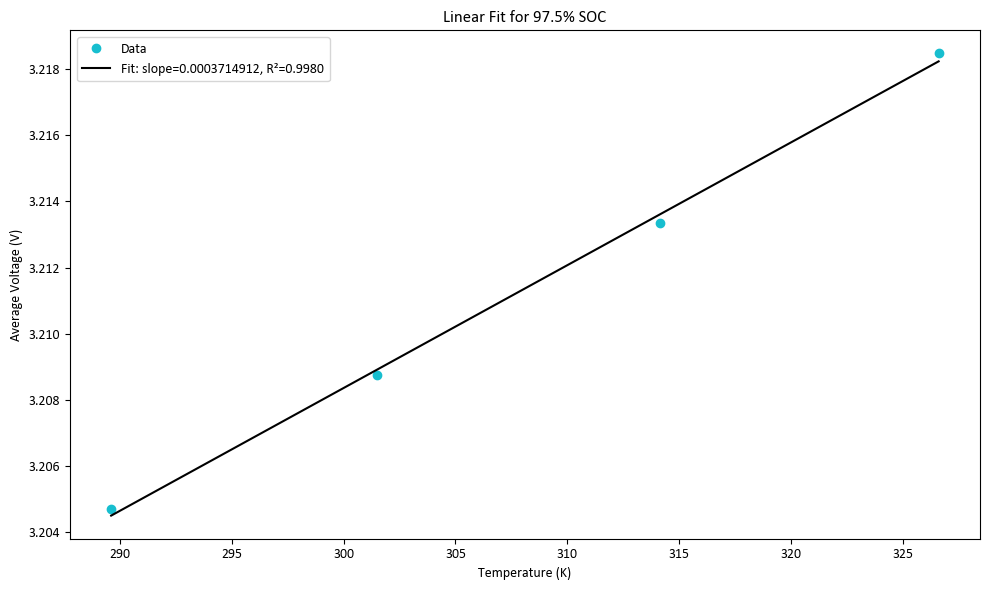

In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
%matplotlib inline

# -------------------------------
# Create output folder
# -------------------------------
output_dir = "Charge_fit_figures_FInal"
os.makedirs(output_dir, exist_ok=True)

# --- Generate a color map ---
soc_labels = avg_table["SOC_label"].unique()
colors = cm.get_cmap("tab10", len(soc_labels))

# --- Loop through SOCs ---
for i, soc in enumerate(soc_labels):

    # Subset SOC data
    soc_data = avg_table[avg_table["SOC_label"] == soc]

    # Reshape data for sklearn
    X = soc_data["Avg_Temp(K)"].values.reshape(-1, 1)
    y = soc_data["Avg_Voltage(V)"].values

    # Fit linear regression
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X)
    slope = reg.coef_[0]
    r2 = r2_score(y, y_pred)

    # --- Plot ---
    plt.figure(figsize=(10, 6))
    plt.plot(X, y, marker='o', linestyle='', color=colors(i), label="Data")
    plt.plot(
        X, y_pred, linestyle='-', color='black',
        label=f"Fit: slope={slope:.10f}, R²={r2:.4f}"
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel("Average Voltage (V)")
    plt.title(f"Linear Fit for {soc}")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()

    # -------------------------------
    # Save figure
    # -------------------------------
    safe_soc = soc.replace("%", "pct").replace(" ", "_")
    filename = f"linear_fit_{safe_soc}.png"
    filepath = os.path.join(output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()


C:\Users\DanWindsor\AppData\Local\Temp\ipykernel_29756\2833734730.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(soc_labels))


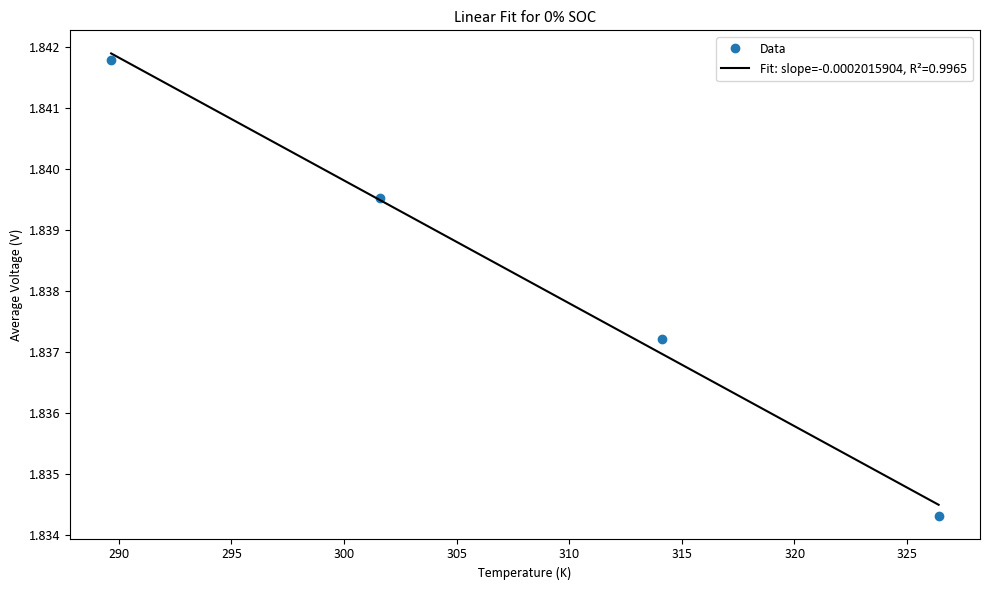

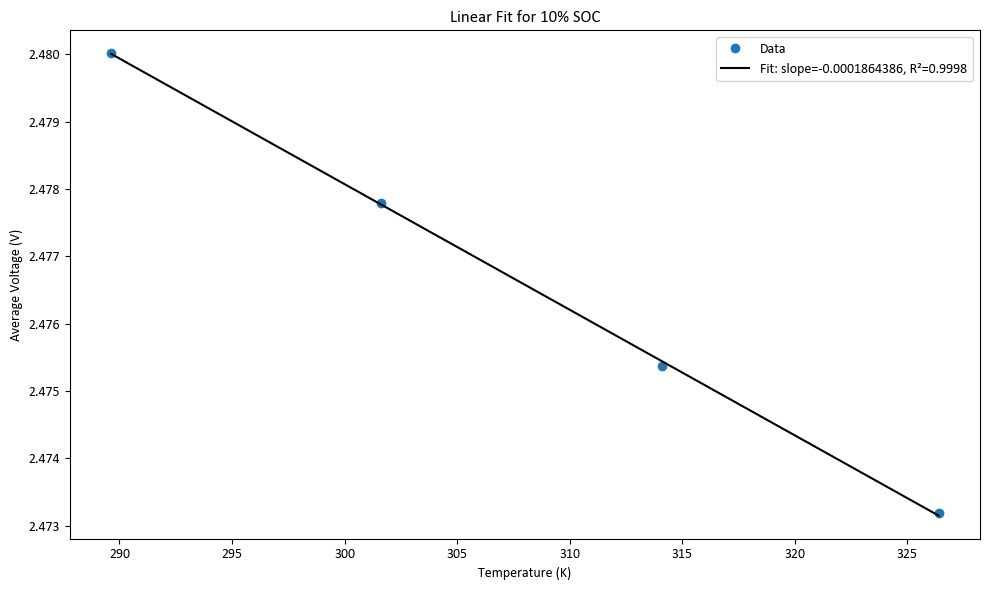

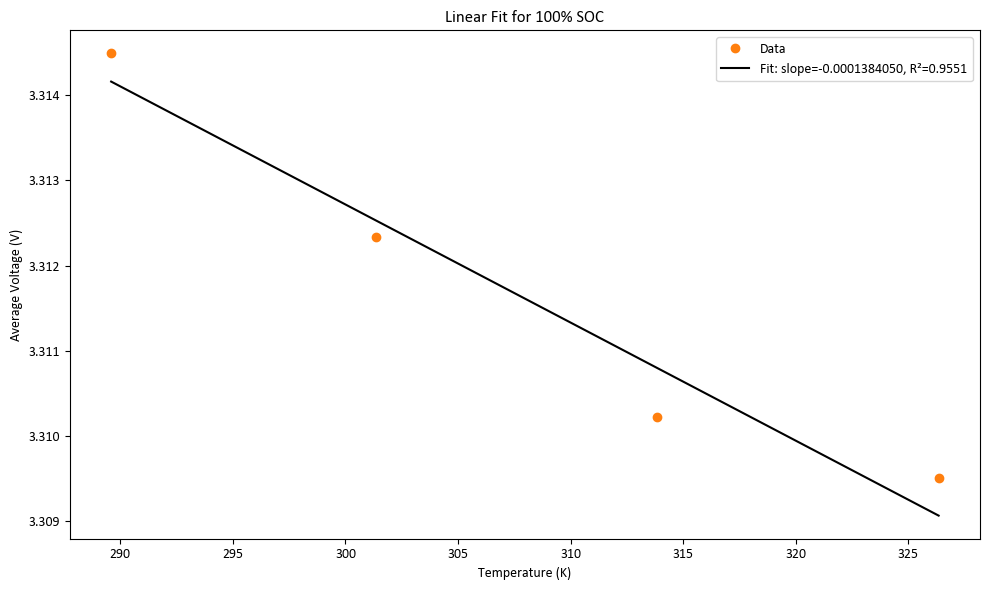

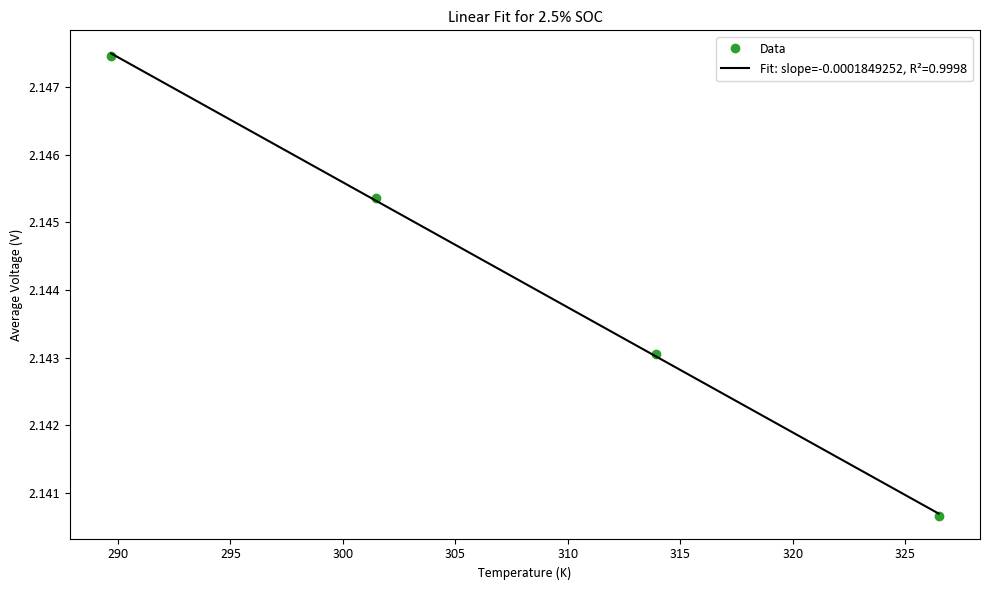

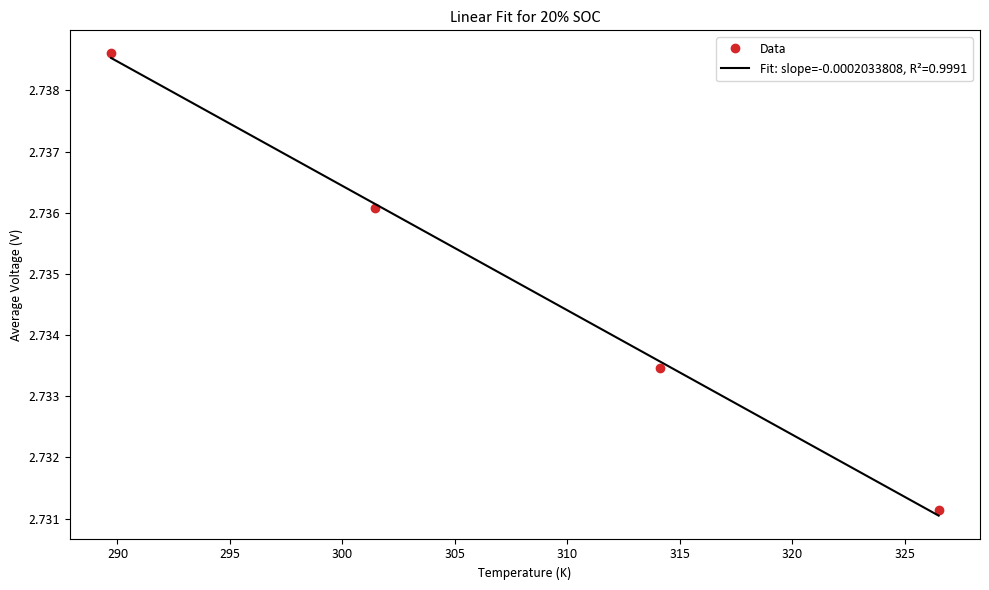

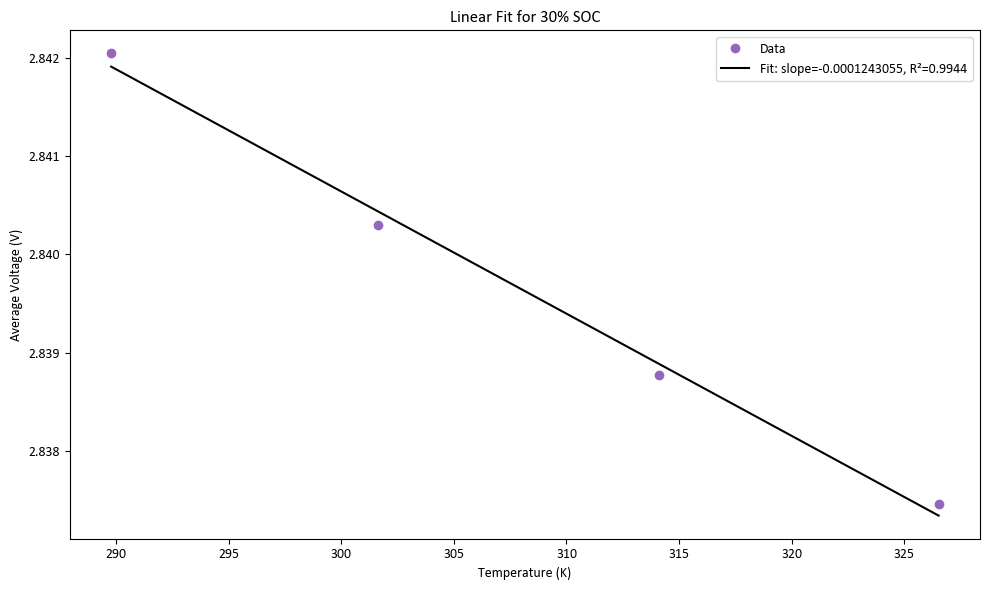

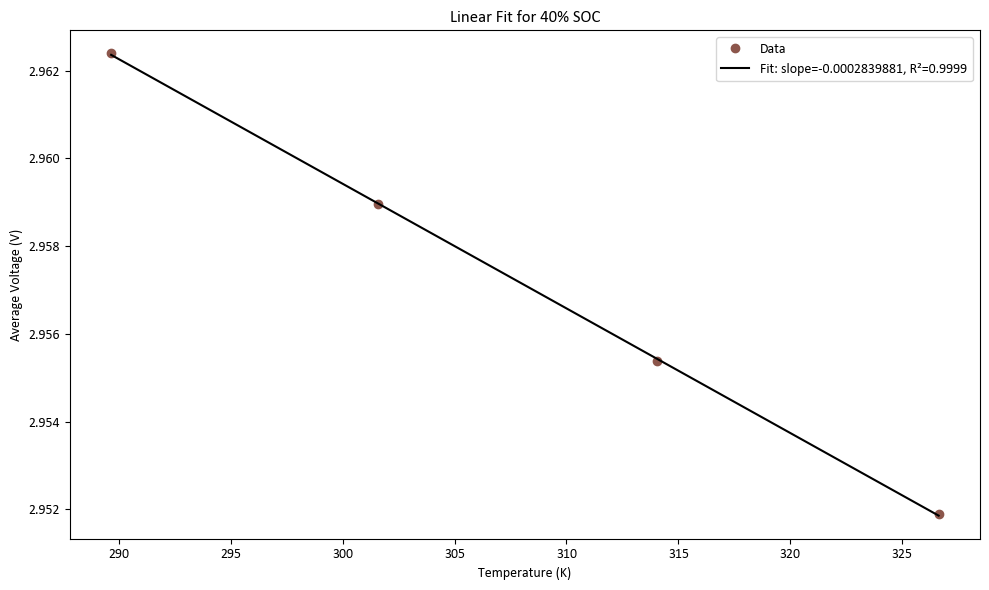

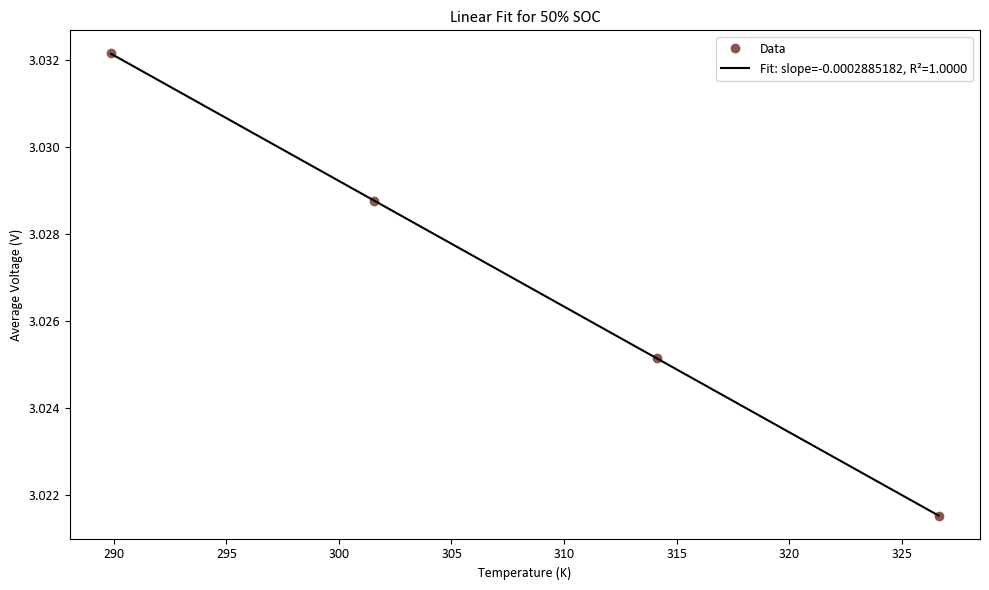

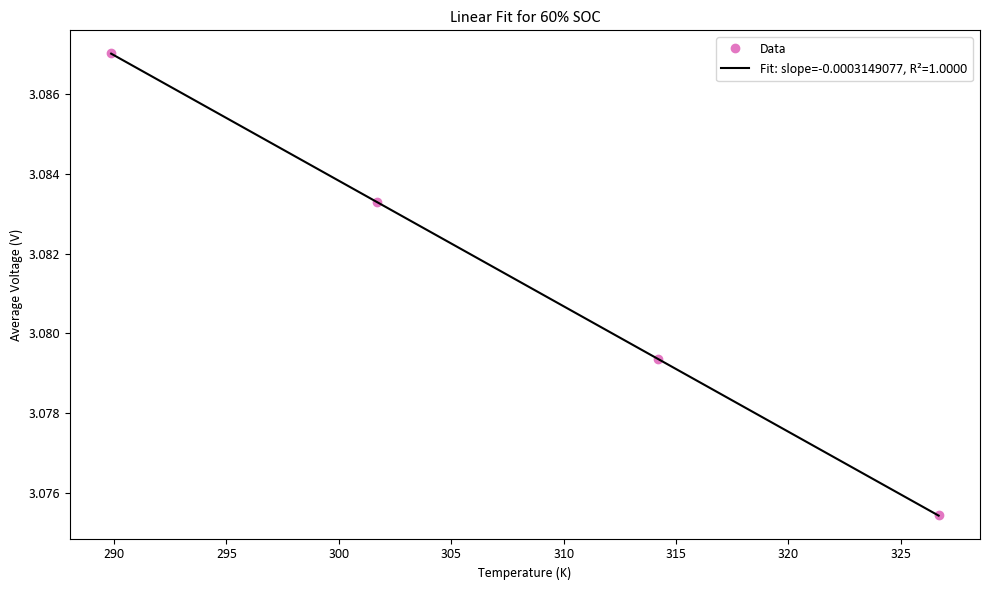

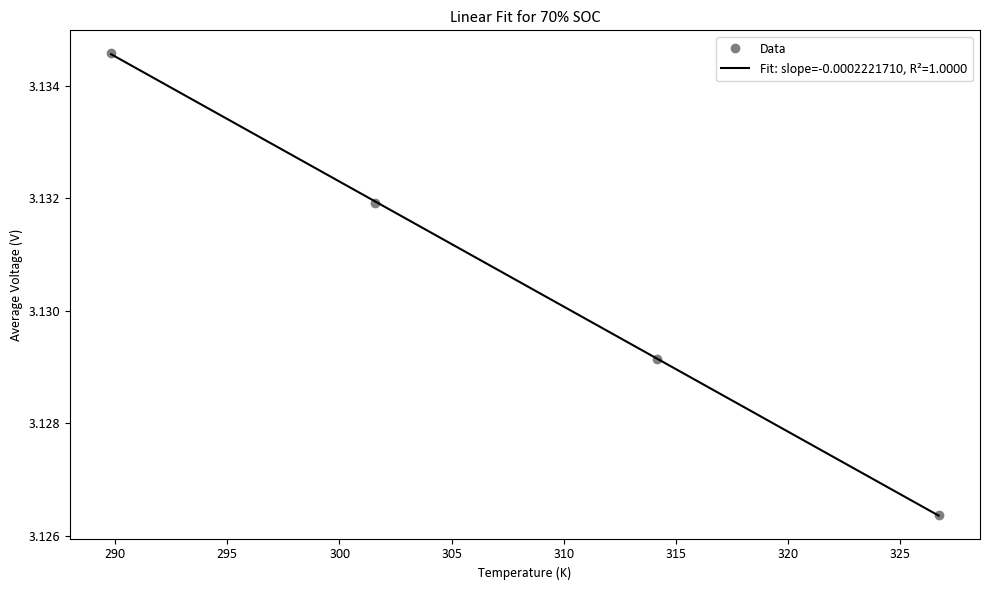

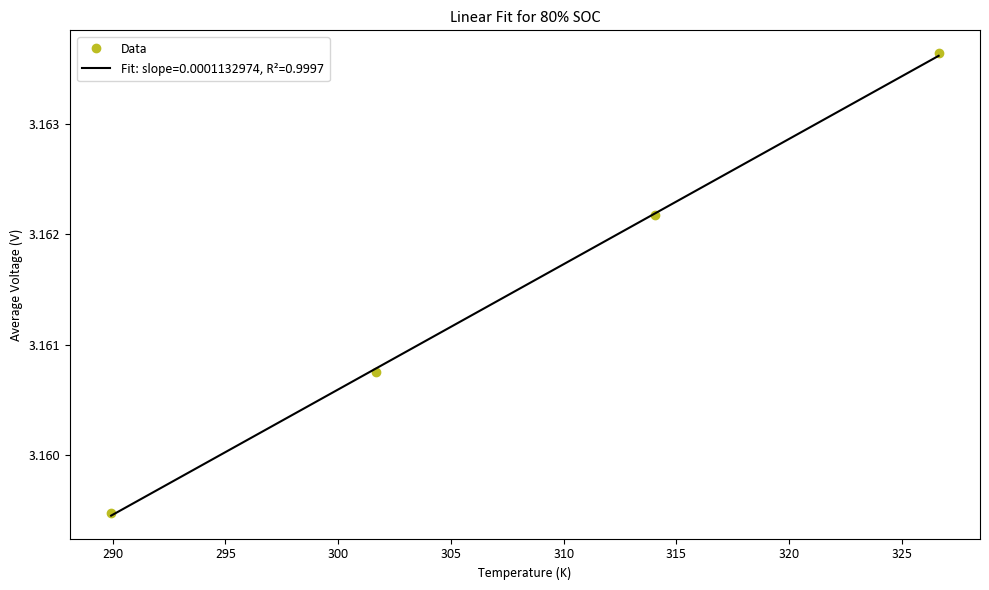

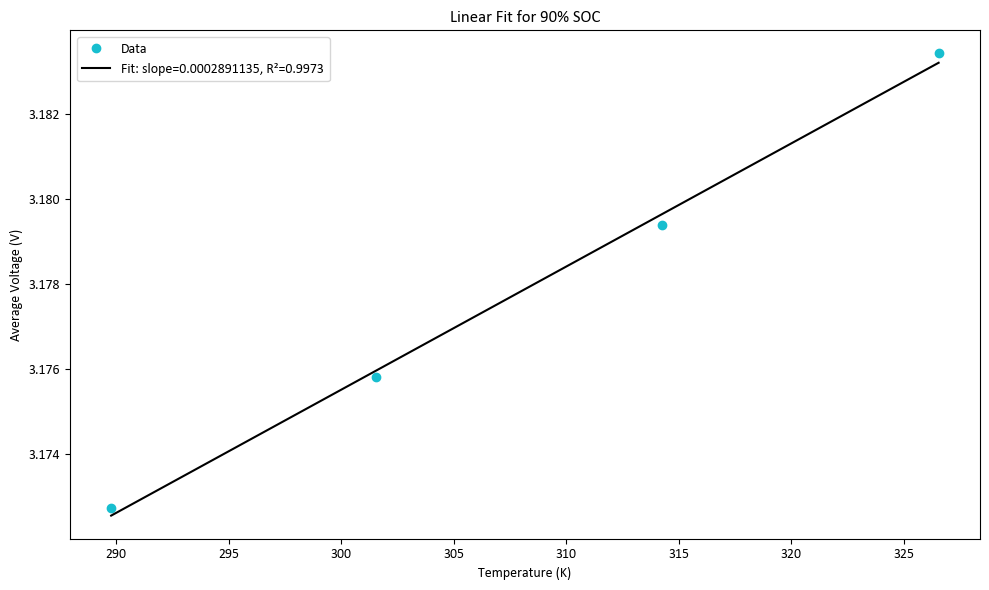

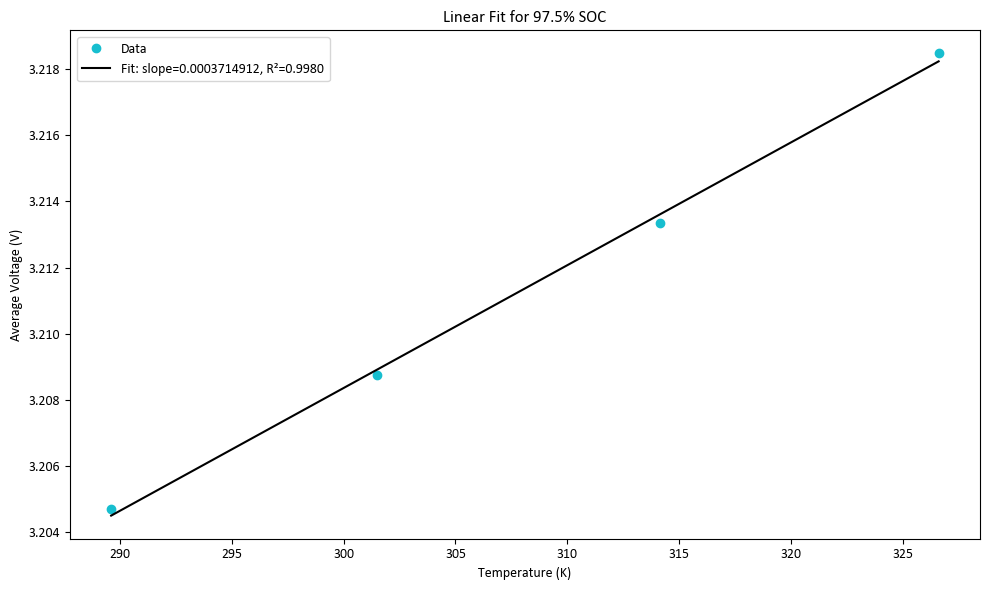

In [15]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
%matplotlib inline

# --- Linear regression on each SOC after exclusions ---

# --- Dictionary of excluded temperature labels per SOC ---
'''
exclude_temps = {
    "100% SOC" : ["60degC"]
}
'''
# --- Generate a color map ---
soc_labels = avg_table["SOC_label"].unique()
colors = cm.get_cmap("tab10", len(soc_labels))

# --- Loop through SOCs ---
for i, soc in enumerate(soc_labels):
    # Subset SOC data
    soc_data = avg_table[avg_table["SOC_label"] == soc]

    # Exclude specific temperatures if defined
    #if soc in exclude_temps:
        #soc_data = soc_data[~soc_data["Temp_label"].isin(exclude_temps[soc])]

    # Skip if no data remains
    #if soc_data.empty:
        #continue

    # Reshape data for sklearn
    X = soc_data["Avg_Temp(K)"].values.reshape(-1, 1)
    y = soc_data["Avg_Voltage(V)"].values

    # Fit linear regression
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X)
    slope = reg.coef_[0]
    r2 = r2_score(y, y_pred)

    # --- Plot with regression line ---
    plt.figure(figsize=(10, 6))
    plt.plot(X, y, marker='o', linestyle='', color=colors(i), label="Data")
    plt.plot(
        X, y_pred, linestyle='-', color='black',
        label=f"Fit: slope={slope:.10f}, R²={r2:.4f}"  # 10 digits for slope
    )
    plt.xlabel("Temperature (K)")
    plt.ylabel("Average Voltage (V)")
    plt.title(f"Linear Fit for {soc}")
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


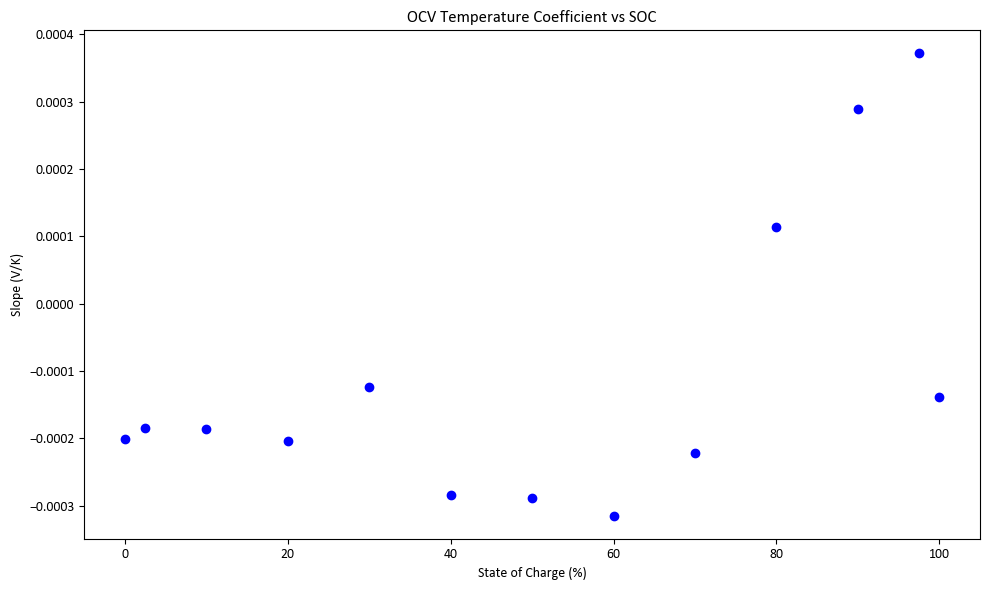

Linear regression slope values (V/K) by SOC:
    SOC_label  Slope(V/K)
0      0% SOC   -0.000202
1     10% SOC   -0.000186
2    100% SOC   -0.000138
3    2.5% SOC   -0.000185
4     20% SOC   -0.000203
5     30% SOC   -0.000124
6     40% SOC   -0.000284
7     50% SOC   -0.000289
8     60% SOC   -0.000315
9     70% SOC   -0.000222
10    80% SOC    0.000113
11    90% SOC    0.000289
12  97.5% SOC    0.000371


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- Extract slopes from the OCV vs. Temp fits for each SOC ---

slope_results = []  # store slope per SOC

for soc in avg_table["SOC_label"].unique():
    # Subset SOC data
    soc_data = avg_table[avg_table["SOC_label"] == soc]

    # Apply temperature exclusions if defined
    #if soc in exclude_temps:
        #soc_data = soc_data[~soc_data["Temp_label"].isin(exclude_temps[soc])]

    # Skip empty groups
    if soc_data.empty:
        continue

    # Fit linear regression
    X = soc_data["Avg_Temp(K)"].values.reshape(-1, 1)
    y = soc_data["Avg_Voltage(V)"].values
    reg = LinearRegression().fit(X, y)

    slope_results.append({
        "SOC_label": soc,
        "Slope(V/K)": reg.coef_[0]
    })

# --- Convert results to a DataFrame ---
slope_df = pd.DataFrame(slope_results)

# --- Convert SOC labels to numeric values for plotting ---
slope_df["SOC_numeric"] = slope_df["SOC_label"].str.replace("% SOC", "").astype(float)

# --- Plot slope vs SOC ---
plt.figure(figsize=(10, 6))
plt.plot(
    slope_df["SOC_numeric"],
    slope_df["Slope(V/K)"],
    marker='o',
    linestyle='none',
    color='blue'
)
plt.xlabel("State of Charge (%)")
plt.ylabel("Slope (V/K)")
plt.title("OCV Temperature Coefficient vs SOC")
#plt.ylim(-0.0002,-0.00005)
plt.grid(False)
plt.tight_layout()
plt.show()

# --- Display the slope table for reference ---
print("Linear regression slope values (V/K) by SOC:")
print(slope_df[["SOC_label", "Slope(V/K)"]])


In [17]:
# --- Save slope results to CSV ---
output_csv = "OCV_dUdT_vs_SOC_VekenGT01_Charge_Final.csv"

# Select only the relevant columns
slope_df_to_save = slope_df[["SOC_label", "Slope(V/K)"]]

# Save to CSV
slope_df_to_save.to_csv(output_csv, index=False)

print(f"✅ Slope values saved to: {output_csv}")


✅ Slope values saved to: OCV_dUdT_vs_SOC_VekenGT01_Charge_Final.csv


In [60]:
import os
import pandas as pd
from IPython.display import FileLink

# -------------------------------
# Save slope results as a CSV file
# -------------------------------

# Create an output directory (optional, prevents Jupyter Lab confusion)
output_dir = r"C:\Users\DanWindsor\Documents"
os.makedirs(output_dir, exist_ok=True)

# Define output path
output_csv = os.path.join(output_dir, "OCV_dUdT_vs_SOC_Prelim_Dec112025.csv")

# Select only the relevant columns
slope_df_to_save = slope_df[["SOC_label", "Slope(V/K)"]]

# Save to CSV (no index)
slope_df_to_save.to_csv(output_csv, index=False)

print(f"✅ Slope values saved to: {output_csv}")

# ----------------------------------
# Provide a guaranteed CSV download
# ----------------------------------
print("\n📥 Click the link below to download the CSV:")
FileLink(output_csv)


✅ Slope values saved to: C:\Users\DanWindsor\Documents\OCV_dUdT_vs_SOC_Prelim_Dec112025.csv

📥 Click the link below to download the CSV:


C:\Users\DanWindsor\Documents\OCV_dUdT_vs_SOC_Prelim_Dec112025.csv

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os
%matplotlib inline

# --- Folder to save figures ---
#save_folder = "DL_Only_OCV_vs_Temp_Figures"
#os.makedirs(save_folder, exist_ok=True)  # create folder if it doesn't exist

# --- Generate a color map based on number of SOCs ---
soc_labels = avg_table["SOC_label"].unique()
colors = cm.get_cmap("tab10", len(soc_labels))  # 'tab10' has 10 distinct colors; adjust if more

# --- Loop over each SOC and create a separate figure with its own color ---
for i, soc in enumerate(soc_labels):
    # Subset for current SOC
    soc_data = avg_table[avg_table["SOC_label"] == soc]

    plt.figure(figsize=(10, 6))
    plt.plot(
        soc_data["Avg_Temp(°C)"],
        soc_data["Avg_Voltage(V)"],
        marker='o',
        linestyle='-',
        color=colors(i)  # assign a unique color per SOC
    )
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Average Voltage (V)")
    plt.title(f"OCV vs Temperature for {soc}")
    plt.grid(False)
    plt.tight_layout()
    plt.show
    
    # --- Save figure to folder ---
    #save_path = os.path.join(save_folder, f"OCV_vs_Temp_{soc.replace('%', 'pct')}.png")
    #plt.savefig(save_path, dpi=300)
    #plt.close()  # close figure to avoid display and free memory

